# Using LightGBM Model

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Load Dataset

In [2]:
def load_dataset(file_path) :
    file_path = Path(file_path)

    if file_path.exists() :
        df = pd.read_csv(file_path, sep=';')
        print('Import Dataset Success')
        return df
    else :
        print("Failed import Dataset")
        return None

In [3]:
file_path = Path('../dataset/diabetes_012_health_indicators_BRFSS2015.csv')
df = load_dataset(file_path)
df

Import Dataset Success


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [4]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.tail()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


# Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


# Exploratory Data Analysist (EDA)

In [8]:
# Check Missing Value
print(df.isna().sum().sort_values(ascending=False))

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [9]:
# Check duplicate Data
duplicate = df.duplicated().sum()
print(f'We have duplicated around {duplicate} ')

We have duplicated around 23899 


In [10]:
# Show 10 duplicated data
duplicates = df[df.duplicated(keep=False)]

duplicates = duplicates.sort_values(by=df.columns.tolist())

duplicates.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


## Visualization Distribution Numerical

In [11]:
# Declare Feature
target = 'Diabetes_012'

def identify_feature(df, target, num_features_dist) :
    cat_features_dist = [
        col for col in df.columns 
        if col not in num_features_dist + [target]
    ]

    return num_features_dist, cat_features_dist

In [12]:
num_features_dist = [
    'BMI',
    'MentHlth',
    'PhysHlth'
]

num_features_dist, cat_features_dist = identify_feature(
    df,
    target=target,
    num_features_dist=num_features_dist
)

for feature in cat_features_dist :
    print(feature)

print('\n')

for feature in num_features_dist :
    print(feature)

HighBP
HighChol
CholCheck
Smoker
Stroke
HeartDiseaseorAttack
PhysActivity
Fruits
Veggies
HvyAlcoholConsump
AnyHealthcare
NoDocbcCost
GenHlth
DiffWalk
Sex
Age
Education
Income


BMI
MentHlth
PhysHlth


In [13]:
# Create Function for Visualization
def plot_num_distribution(
        df,
        feature,
        figsize=(7,7),
        kde=True
) :
    for col in feature :
        plt.figure(figsize=figsize)
        sns.histplot(
            data=df,
            x=col,
            kde=kde,
            element='step'
        )
        plt.title(f"Distribution of {col}")
        plt.show()

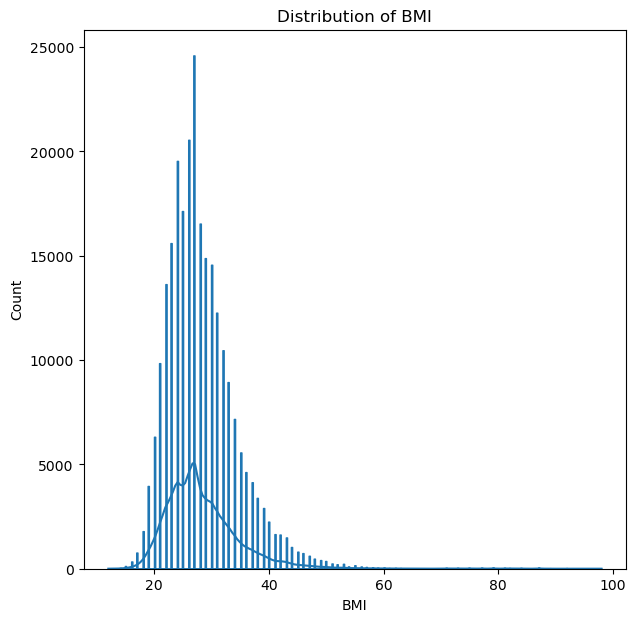

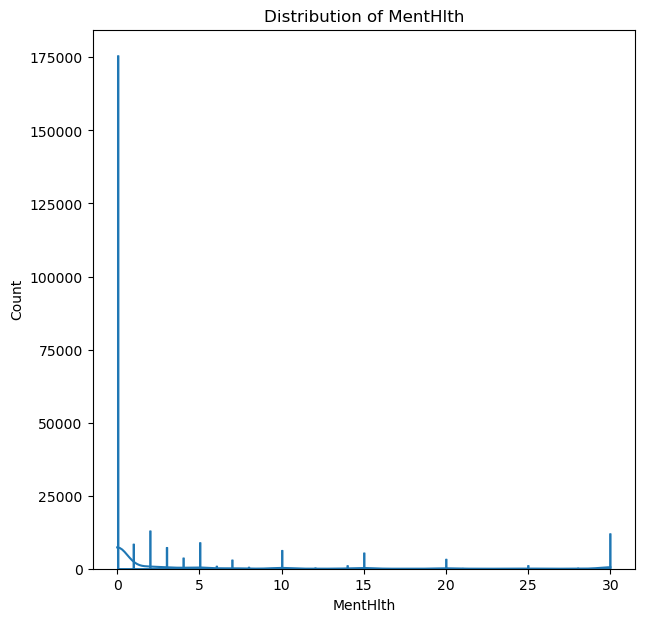

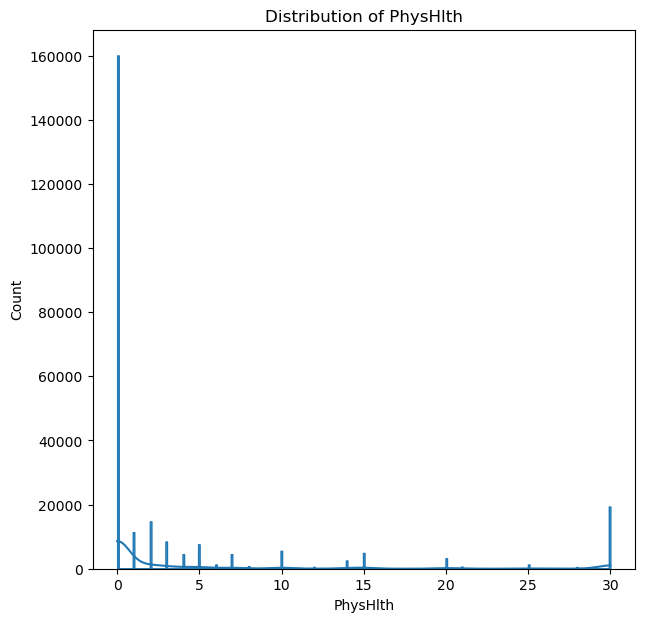

In [14]:
plot_num_distribution(
    df,
    num_features_dist,
)

## Interpretation Visualization Numerical Features
1. BMI = The distribution is right-skewed (positive skew) the majority of values ​​cluster within the 20–35 range, with a peak (mode) around 27–28. This makes medical sense a BMI of 25–29.9 is categorized as "overweight," so it is natural for the general health survey population to be concentrated in this range. The long right hand tail extending to a BMI of 80–100 indicates a small number of respondents with extreme obesity, or potential outliers/data entry errors requiring further verification (BMIs above 60–70 are clinically very rare). The KDE curve (smooth blue line) confirms a unimodal pattern with right skewness.

2. MenHlth & PhysHlth : The majority of respondents (>150,000 people) reported zero days with issues—meaning that, overall, this population was mentally and physically healthy over the past month. Only a small fraction reported a few days with issues, while another small group (showing a spike at the 30-day mark) experienced health problems every day throughout the month—likely a group with chronic conditions (such as long-term mental illness or chronic physical ailments).

## Visualization Distribution Categorical

In [15]:
def plot_cat_distributions (
        df, 
        feature,
        figsize=(7,7),
):
    for col in feature :
        count_feature = df[col].value_counts().index
        plt.figure(figsize=figsize),
        ax = sns.countplot(
            data=df,
            x=col,
            order=count_feature
        )
        ax.bar_label(ax.containers[0])
        plt.title(f'Distribution of {col}')
        plt.show()

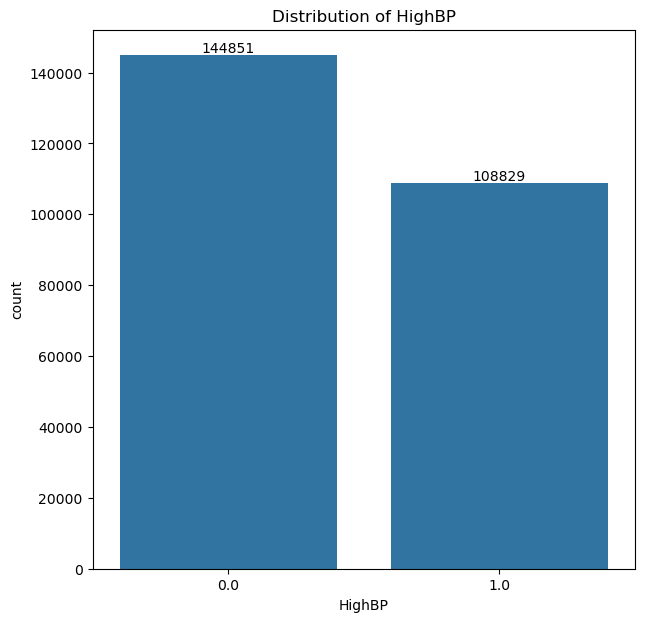

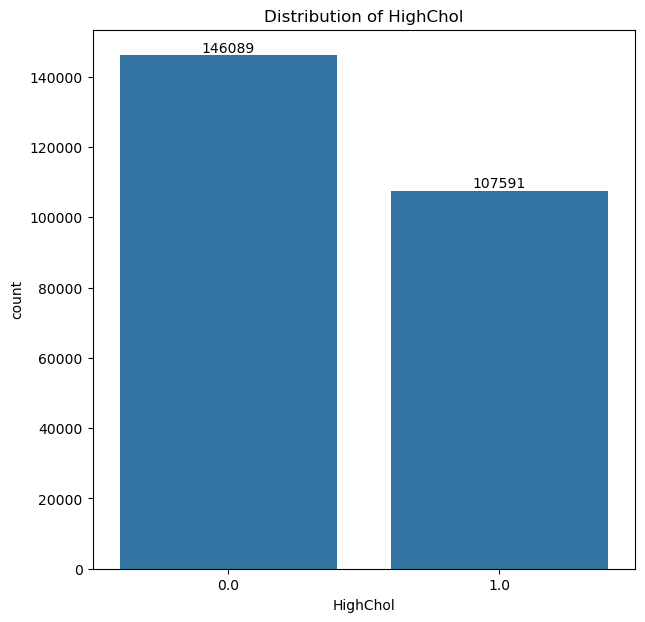

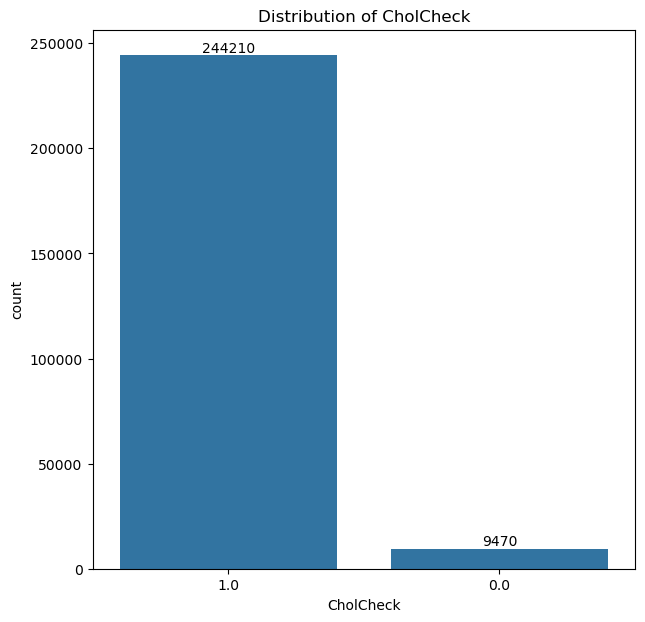

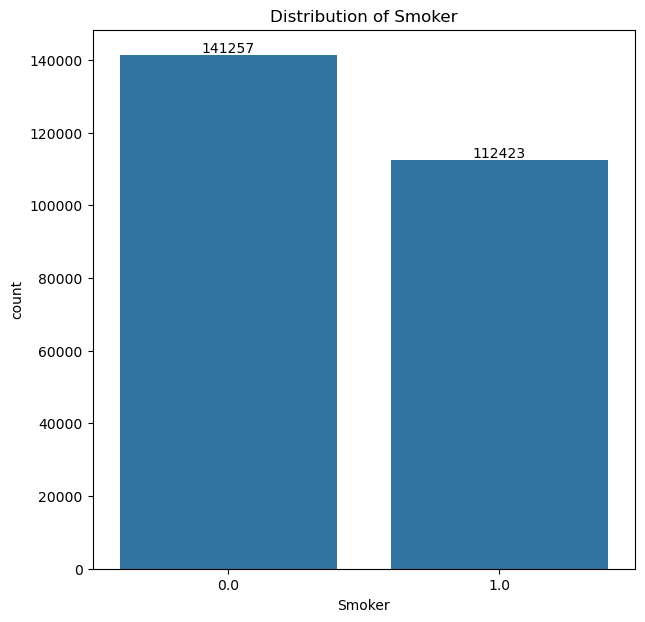

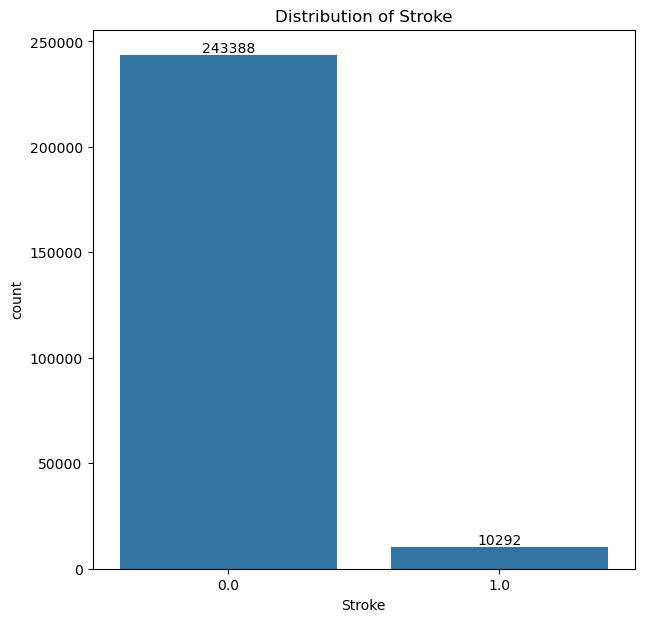

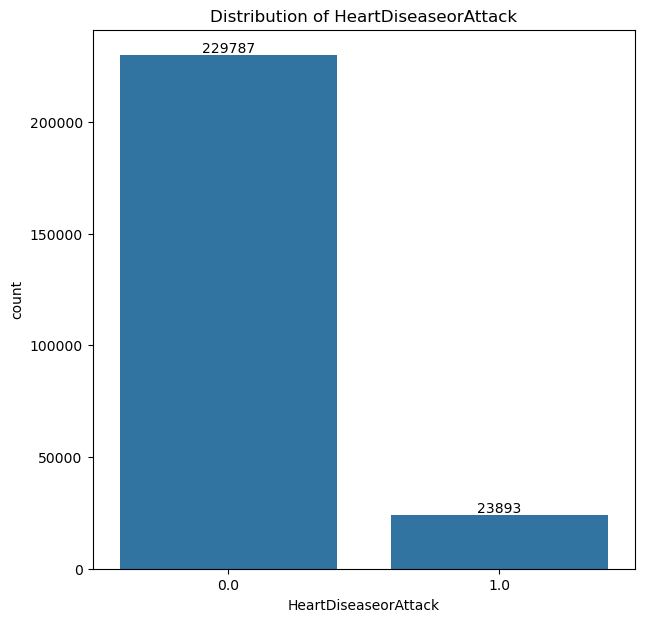

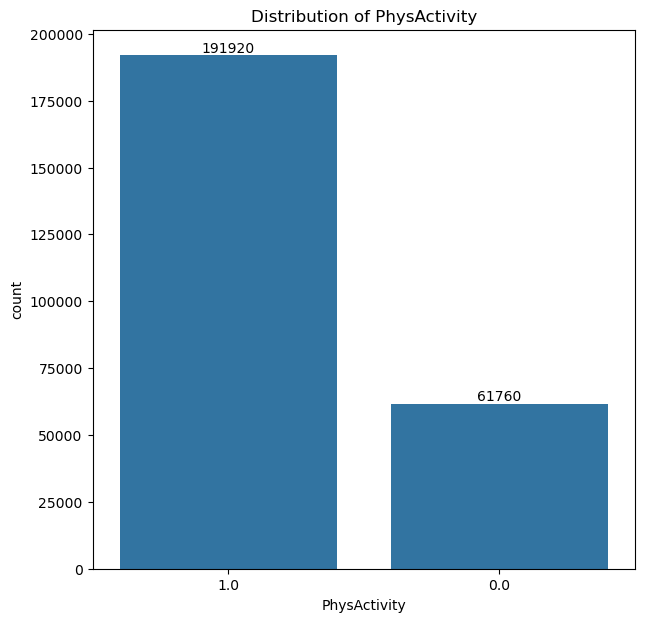

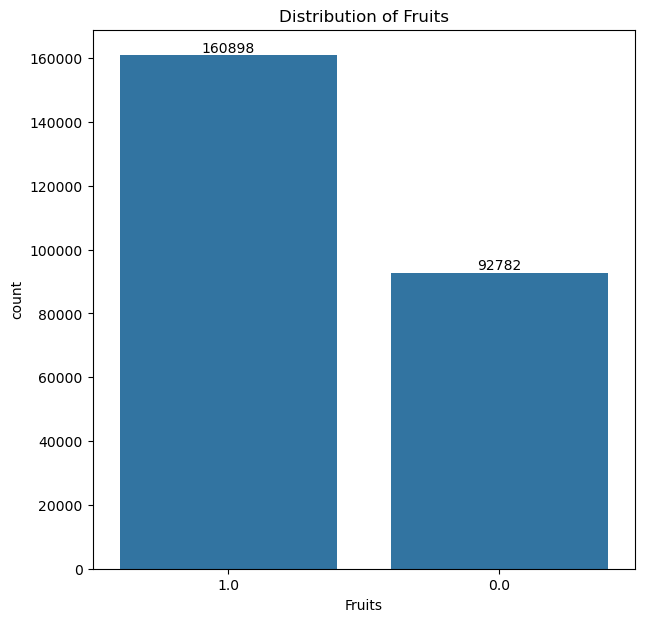

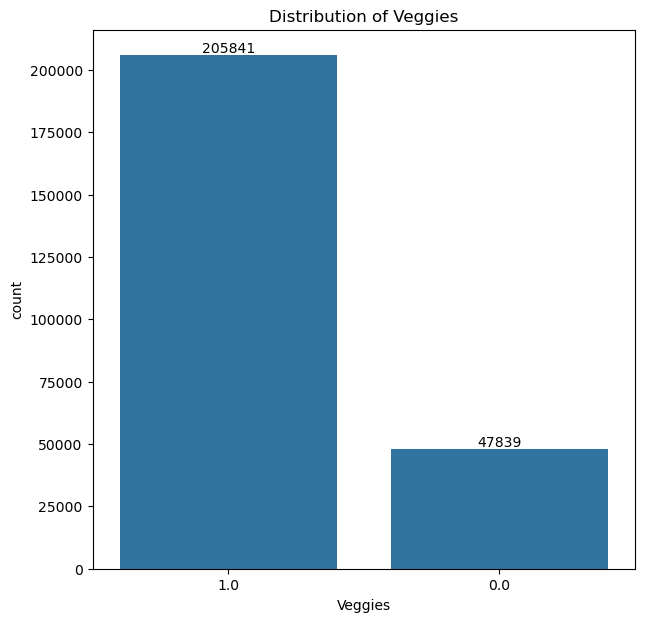

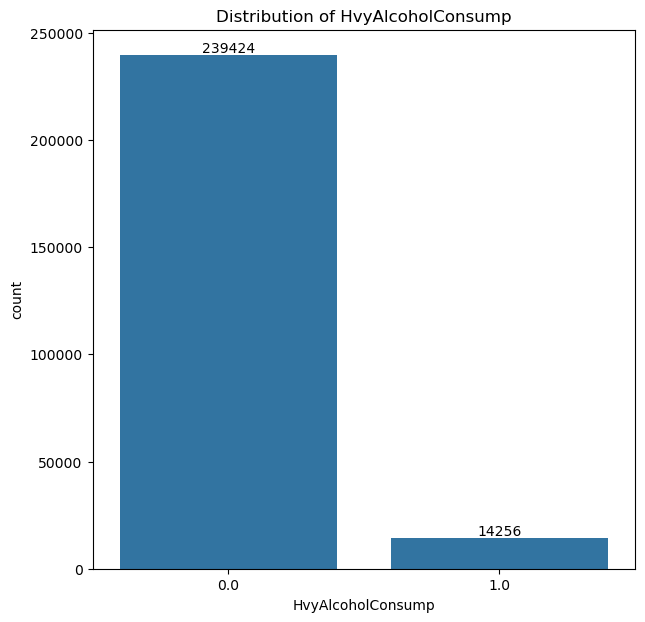

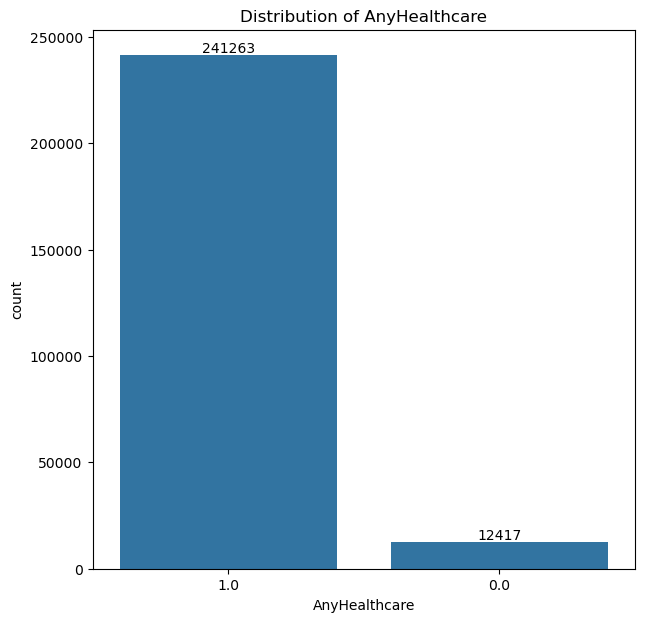

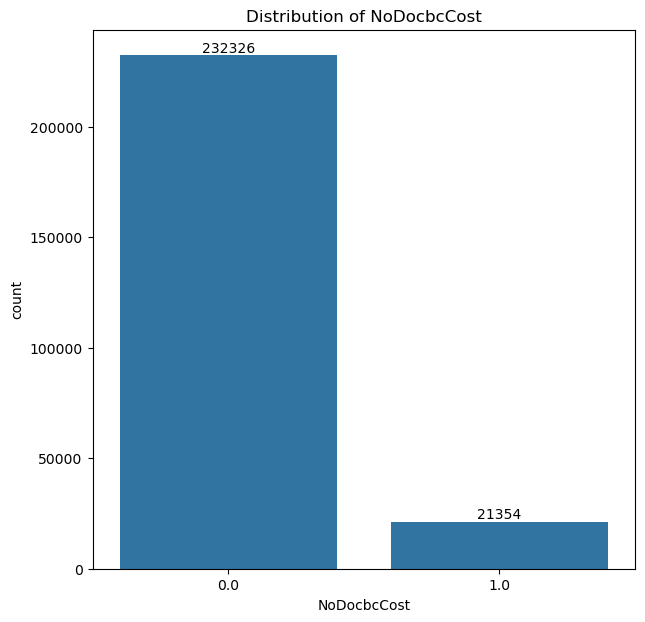

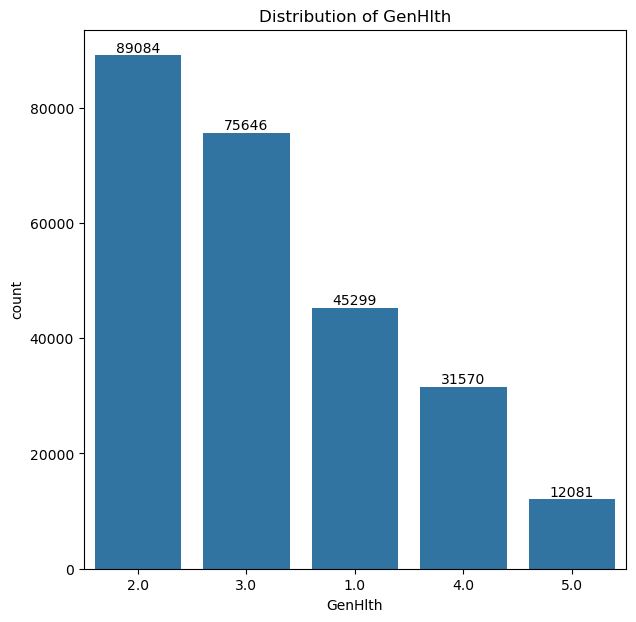

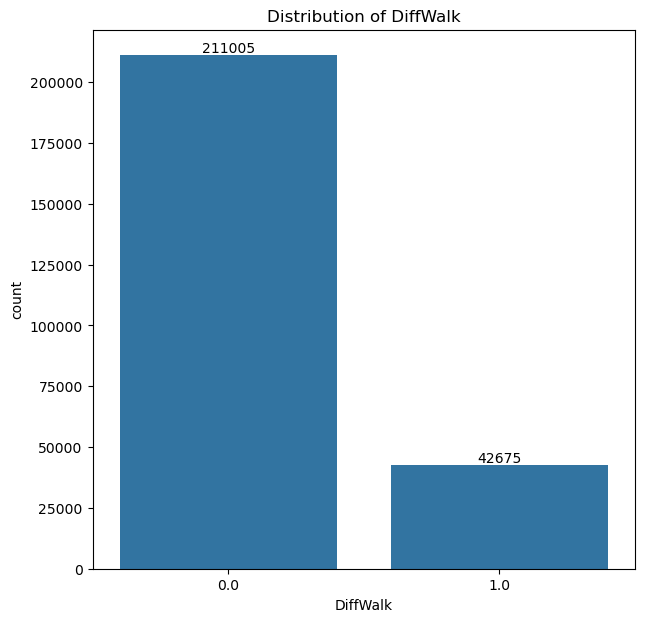

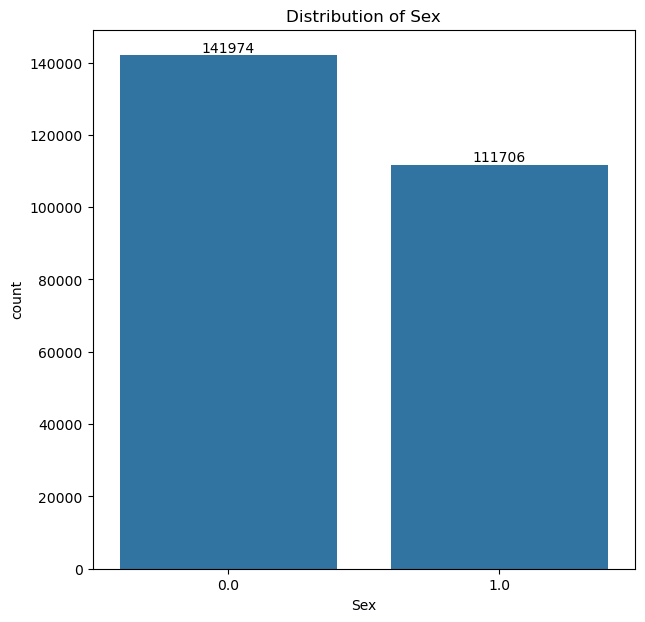

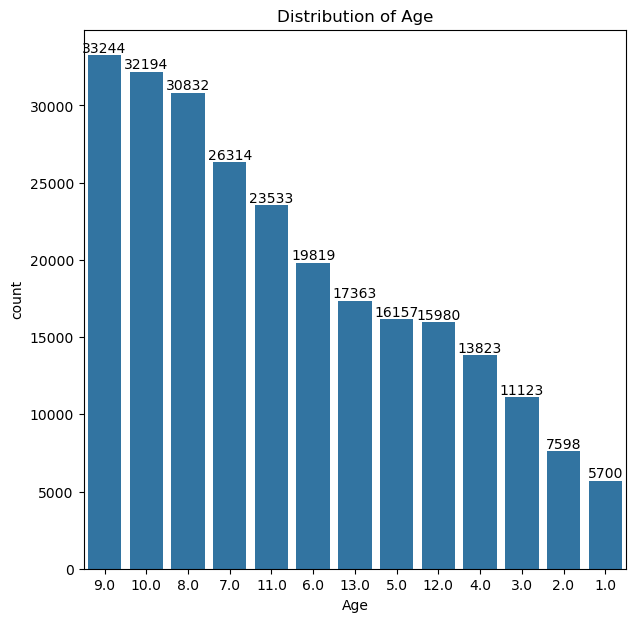

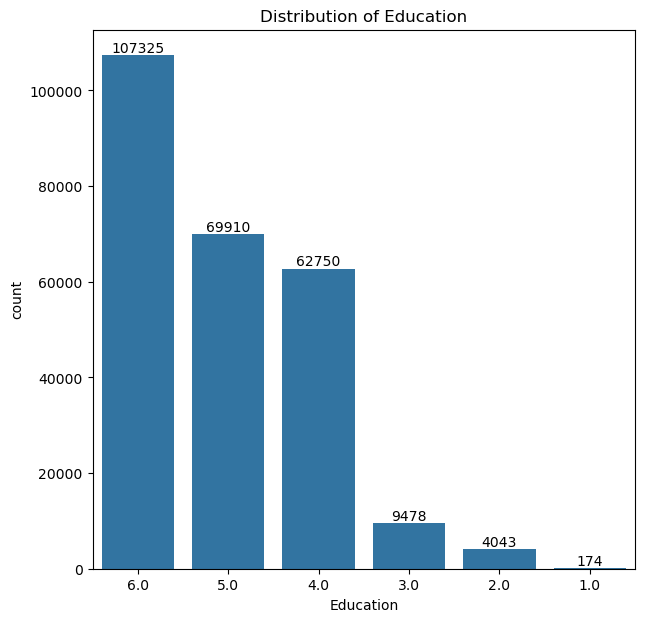

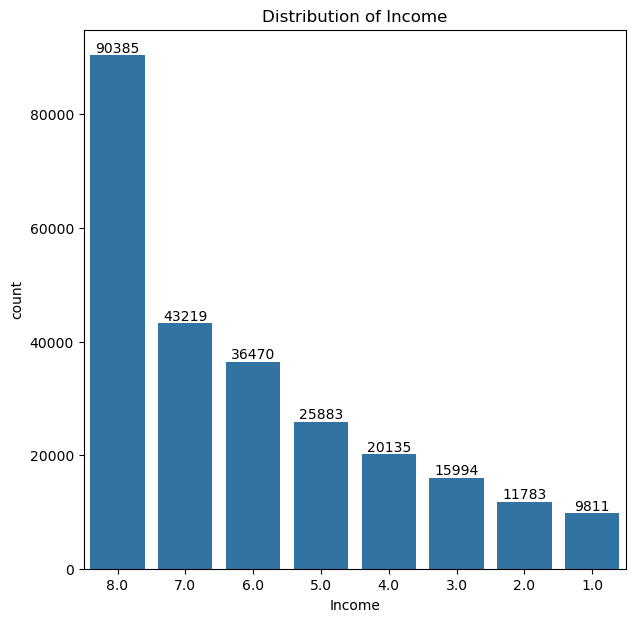

In [16]:
plot_cat_distributions(
    df,
    cat_features_dist
)

## Interpretation Visualization Categorical Features
1. HighBP, HighChol: Fairly balanced—approximately 43% of respondents had high blood pressure, and 42% had high cholesterol. There is no significant imbalance, meaning these features offer good variation for distinguishing between target classes.

2. Stroke (10,292 = 4%), HeartDiseaseorAttack (23,893 = 9.4%): Highly imbalanced—which is expected, as strokes and heart attacks are relatively rare conditions in the general population. Despite their low prevalence, such features are often highly predictive of diabetes, as a history of stroke or heart disease is strongly correlated with metabolic disorders.

3. HvyAlcoholConsump (14,256 = 5.6%): Highly imbalanced; the majority of respondents were not heavy drinkers.

4. Smoker: Fairly balanced (44% smokers vs. 56% non-smokers).

5. PhysActivity (76% active), Fruits (63% consumption), Veggies (81% consumption): The majority of respondents reported a relatively healthy lifestyle—a common occurrence in self-reported health survey data (social desirability bias: people tend to report good habits).

6. CholCheck (96%), AnyHealthcare (95%), and NoDocbcCost (8.4%): These three features are highly imbalanced—almost all respondents have access to healthcare and undergo regular cholesterol checks, while very few avoid doctor visits due to cost. Due to this lack of variation, their potential contribution to the diabetes prediction model is likely low compared to other features; while LightGBM will automatically assign low importance to such features, it is worth noting this in the report as a preliminary observation.

7. GenHlth (scale 1–5, 1 = excellent, 5 = poor): The distribution skews toward the "good" category (with 2 and 3 being the most common, ~65% combined), while fewer respondents report "poor" general health (5; only 12,081 individuals or 4.8%). This is a highly valuable feature as it represents the respondents' perception of their overall health—typically one of the strongest predictors of diabetes in datasets of this type.

8. Age(codes 1–13, representing 5-year age groups): The distribution drops sharply from code 9 to code 1—meaning there are more respondents in the middle-to-older age groups (codes 9–10, roughly ages 60–65) and fewer in the youngest group (code 1, ages 18–24).

9. Education (scale 1–6, 6 = highest): Heavily skewed toward higher education—the majority of respondents fall into categories 6 (≥college graduate) and 5, whereas category 1 (no schooling/elementary school) is virtually non-existent (only 174 individuals). This indicates a higher-education bias within the survey population.

10. Income (scale 1–8, 8 = highest): A similar pattern—skewed towards high income, with category 8 (>$75k) dominating (90,385 respondents, ~36%) and gradually decreasing towards the lower categories.

## Target Distribution

In [17]:
def target_distribution (
        df,
        target,
        figsize=(7,7)
):
    count_feature = df[target].value_counts().index
    plt.figure(figsize=figsize),
    ax = sns.countplot(
           data=df,
            x=target,
            order=count_feature
        )
    ax.bar_label(ax.containers[0])
    plt.title(f'Distribution of {target}')
    plt.show()

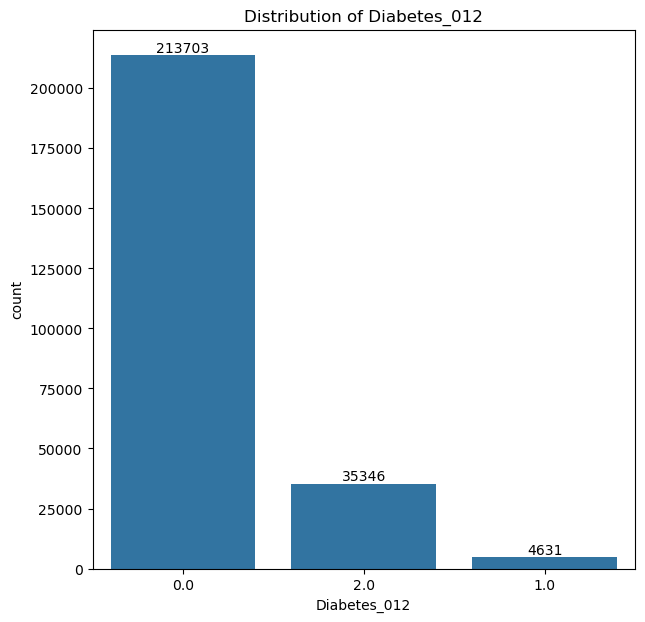

In [18]:
target_distribution(
    df,
    target
)

## Interpretasion Distribution Target

Class 0 is the highest respons with 213703 which mean is good we have 213703 population no Diabetes, class 2 around 35346 and class 1 4631. But this data imbalance we have to handle it

## Visualization Numerical Features vs Target

In [19]:
def num_vs_target(
        df,
        feature,
        target,
        figsize=(7,7),
        kde=True
):
    for col in feature :
        plt.figure(figsize=figsize)
        sns.histplot(
            data=df,
            x=col,
            hue=target,
            kde=kde,
            element='step',
            palette=['steelblue', 'orange', 'seagreen'],
            stat='density',
            common_norm=False
        )
        plt.title(f"{col} VS {target}")
        plt.show()

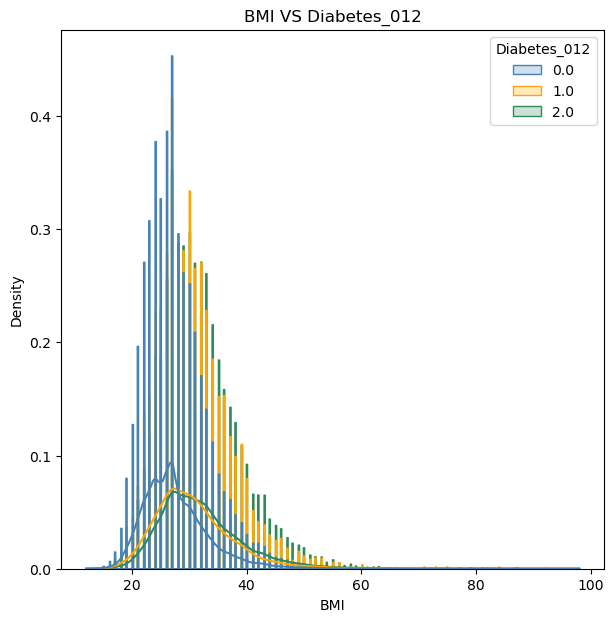

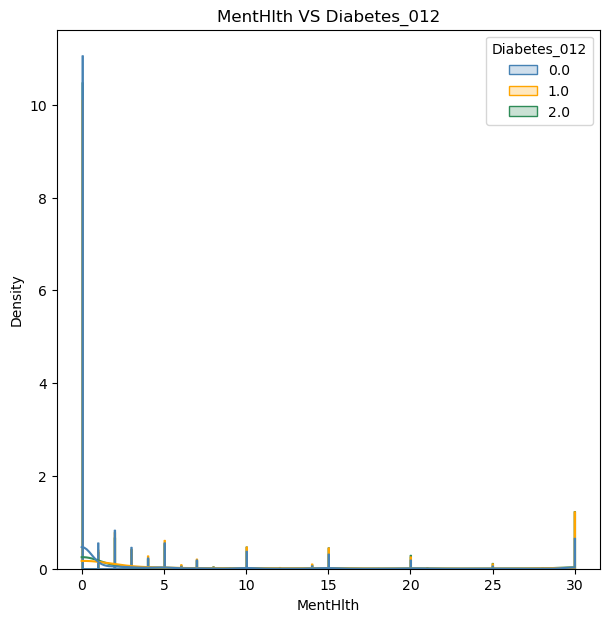

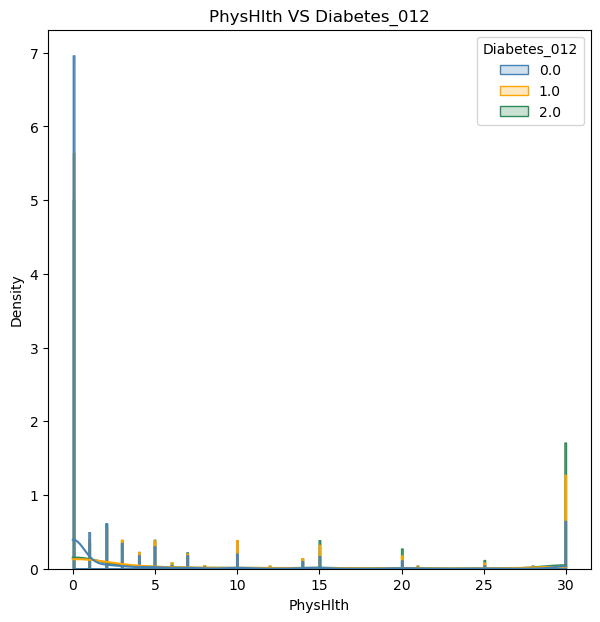

In [20]:
num_vs_target(
    df,
    num_features_dist,
    target
)

## Interpretation
I think hist plot its no good choice for these data because of to many zero in data in will make grafik not move, so i'll make new visualization with violin

In [21]:
def num_violin(
        df,
        feature,
        target,
        figsize=(7,7)
):
    for col in feature :
        plt.figure(figsize=figsize)
        sns.violinplot(
            data=df,
            x=target,
            y=col,
            inner='box'
        )
        plt.title(f"{col} VS {target}")
        plt.show()

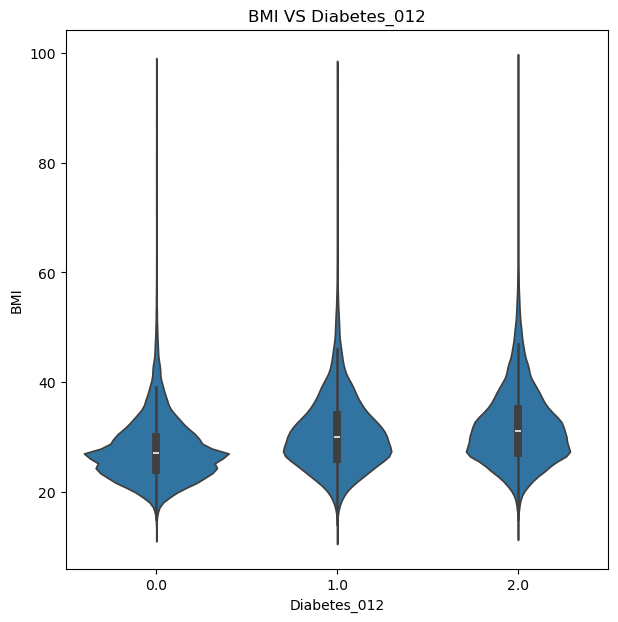

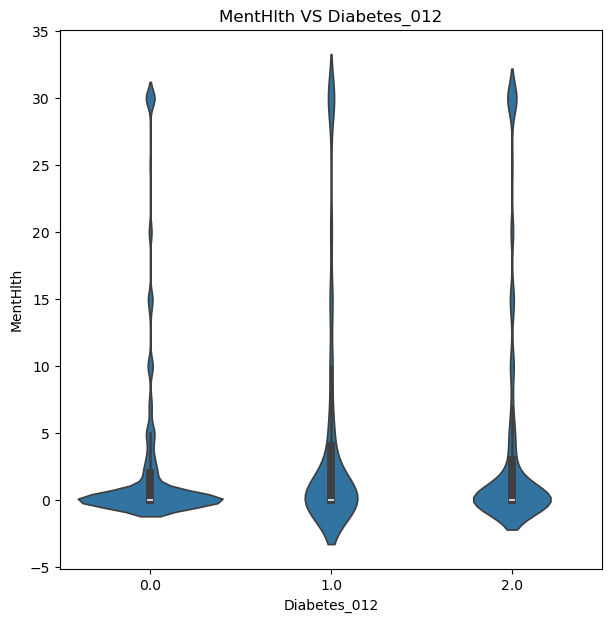

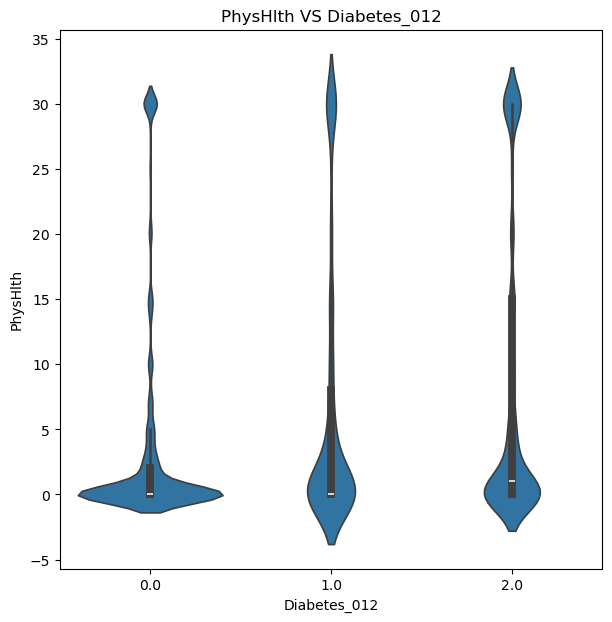

In [22]:
num_violin(
    df,
    num_features_dist,
    target
)

## Interpretation Violin
1. BMI = This is the most informative of the three. All three classes (0 = no diabetes, 1 = prediabetes, 2 = diabetes) share a similar shape—bulging around a BMI of 25–30 with a long upper tail. However, a closer look reveals a slight shift: the "violin bodies" for classes 1 and 2 are somewhat wider and shifted to the right (indicating a higher median) compared to class 0. This implies that BMI tends to be higher in individuals with prediabetes or diabetes, although there is still significant overlap between the classes.

2. MentHlth — The violin shapes for the three classes are nearly identical; they all show a thin accumulation at Y=0 with small bulges at certain points (2–3, 15, 30). Visually, the differences between classes are very subtle and difficult to interpret based solely on the violin shapes—confirmation via proportion figures is required (see the `had_bad_MentHlth` calculation ).

3. PhysHlth — Unlike MentHlth, classes 1 and 2 exhibit a thicker violin "neck" in the 5–15 range and a larger bulge at Y=30 compared to class 0. This indicates a higher proportion of physical health issues in the prediabetes/diabetes groups—a pattern subsequently confirmed by the proportion calculations in the next cell (34.1% → 46.6% → 52.6%).

In [23]:
# Rata-rata dan median per kelas — angka pasti, bukan tebakan dari bentuk violin
df.groupby('Diabetes_012')[['BMI', 'MentHlth', 'PhysHlth']].agg(['mean', 'median'])

# Proporsi yang melaporkan MINIMAL 1 hari bermasalah, per kelas
for col in ['MentHlth', 'PhysHlth']:
    df[f'had_bad_{col}'] = (df[col] > 0).astype(int)
    print(f"\n{col} > 0 per kelas:")
    print(df.groupby('Diabetes_012')[f'had_bad_{col}'].mean() * 100)


MentHlth > 0 per kelas:
Diabetes_012
0.0    30.126858
1.0    36.169294
2.0    33.788830
Name: had_bad_MentHlth, dtype: float64

PhysHlth > 0 per kelas:
Diabetes_012
0.0    34.094982
1.0    46.642194
2.0    52.639620
Name: had_bad_PhysHlth, dtype: float64


The pattern shows a monotonic increase: 34.1% → 46.6% → 52.6%. This means that the more severe the diabetes, the higher the proportion of people reporting at least one day of physical health issues in the past month. The difference is also substantial—people with diabetes (Type 2) are nearly 1.5 times more likely to report days with physical health issues compared to those without diabetes (52.6% vs. 34.1%).

The pattern is not monotonic: 30.1% (Class 0) → 36.2% (Class 1) → 33.8% (Class 2). Class 1 (prediabetes) actually has the highest proportion, rather than Class 2 (diabetes) as previously inferred from the violin plot shape. The differences between the three classes are also much smaller compared to PhysHlth (a range of only 6 percent, versus 18 percentage points for PhysHlth).

## Visualization Categorical VS Target

In [24]:
def cat_vs_target(
        df,
        feature,
        target,
        figsize=(7,7),
):
    for col in feature :
        count_feature = df[col].value_counts().index
        plt.figure(figsize=figsize)
        ax = sns.countplot(
           data=df,
            x=col,
            hue=target,
            order=count_feature,
            palette=['steelblue', 'orange', 'seagreen'],

        )
        for containers in ax.containers :
            ax.bar_label(containers)
        plt.title(f"{col} VS {target}")
        plt.show()

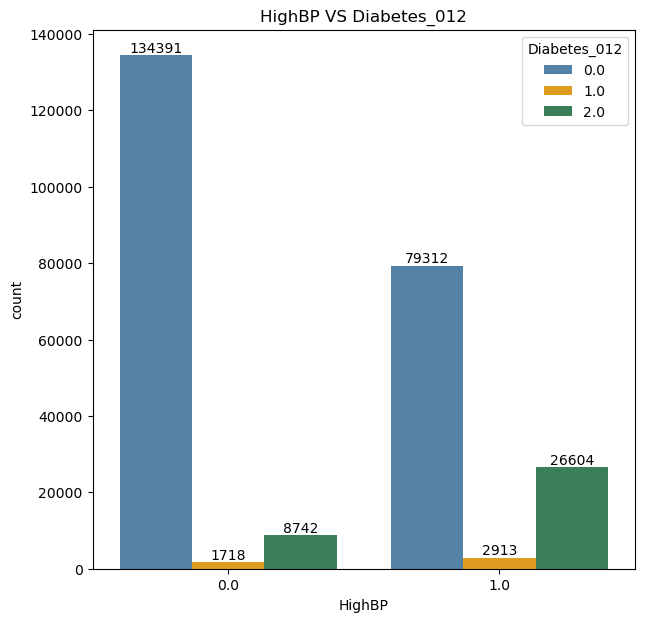

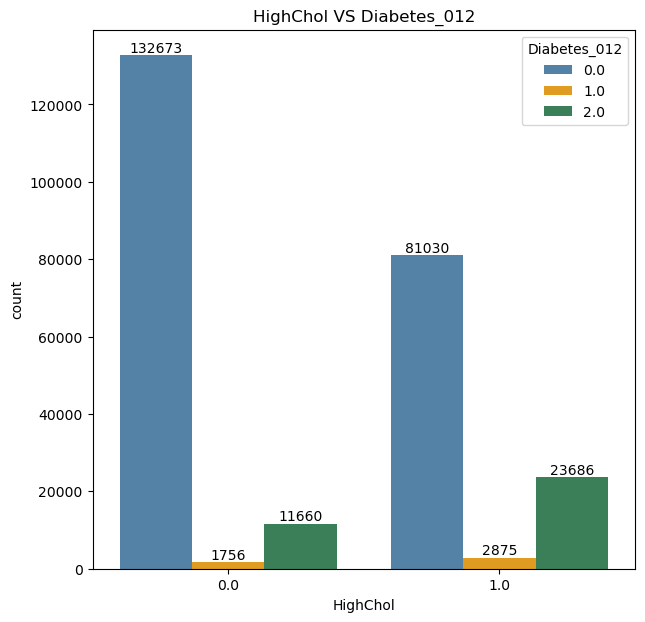

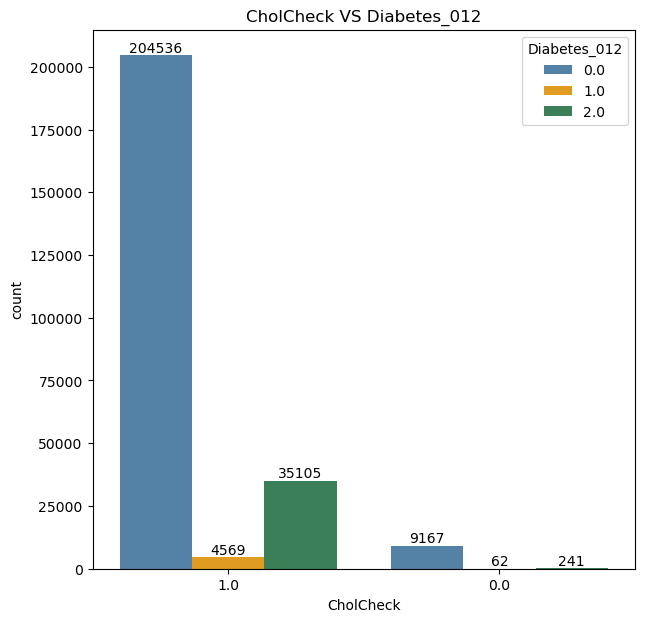

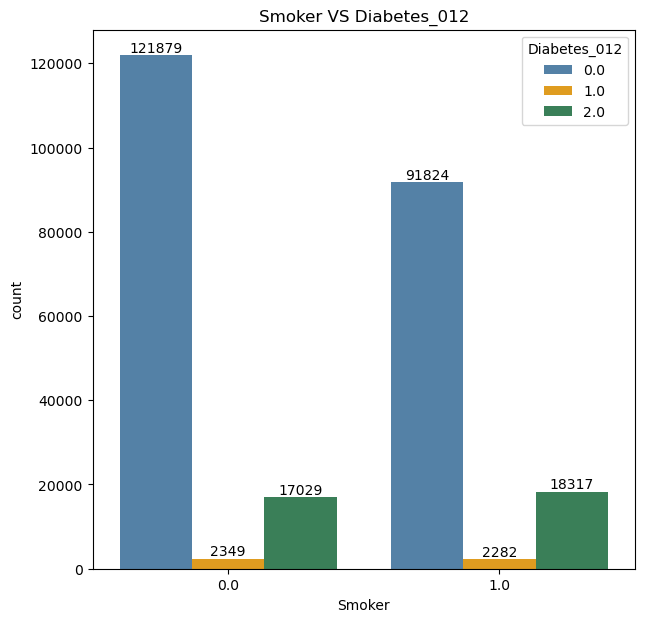

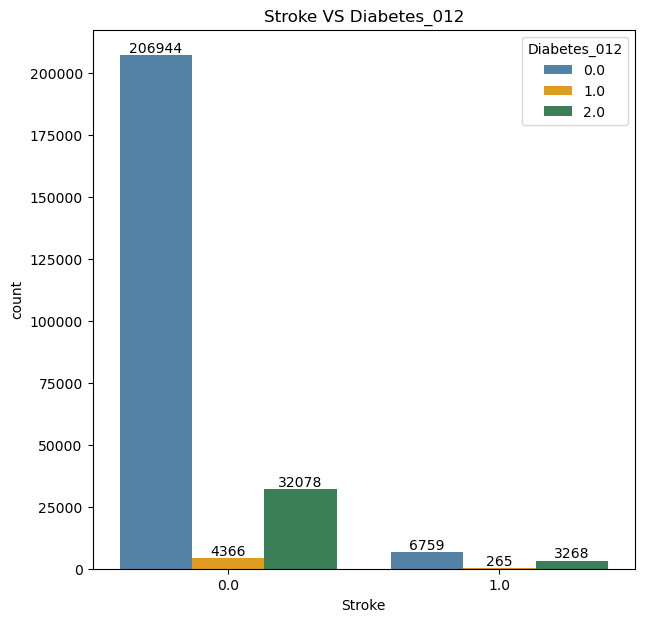

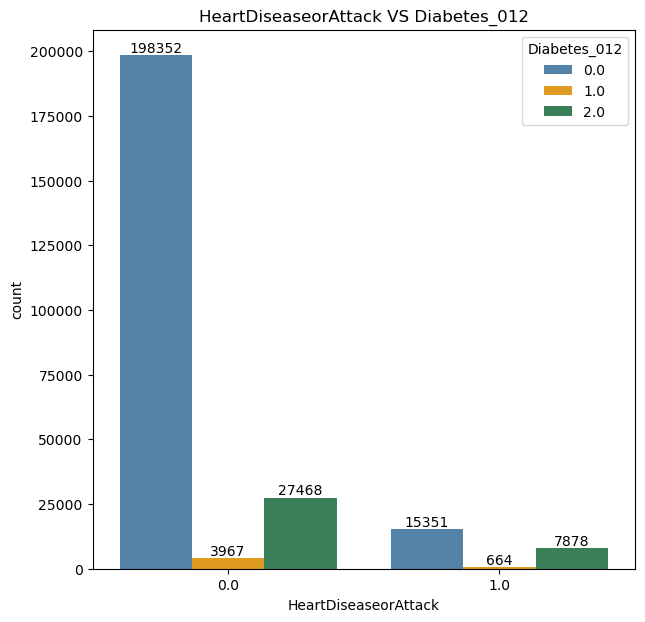

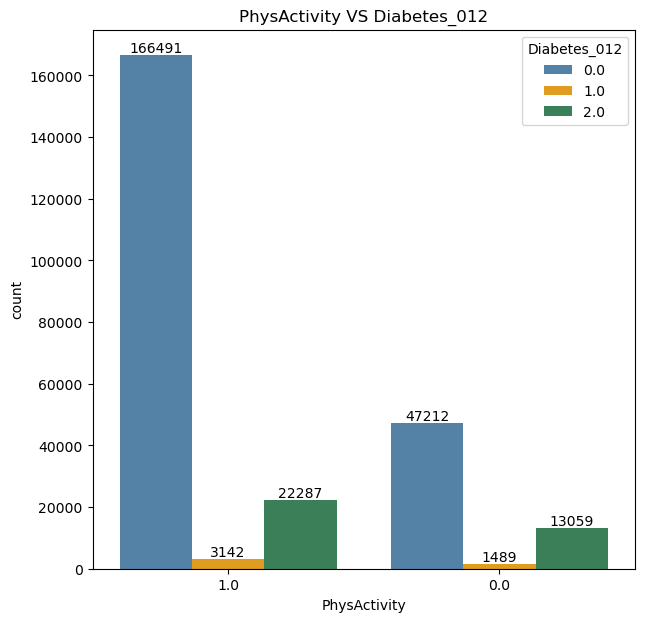

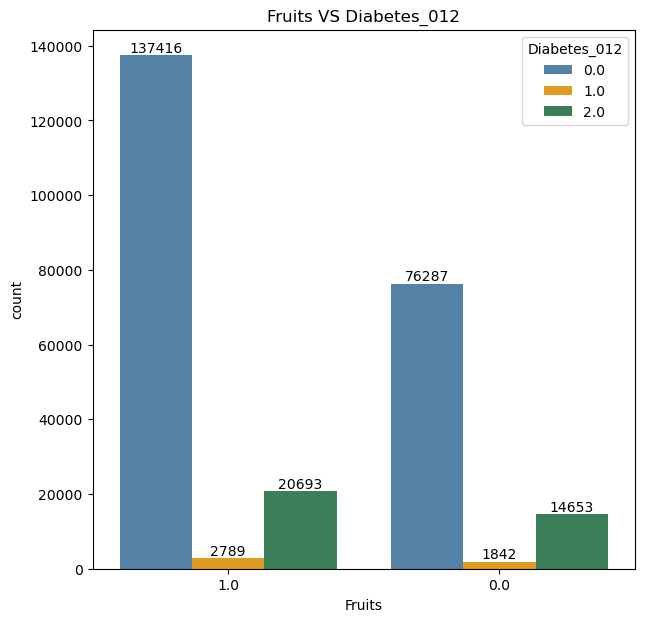

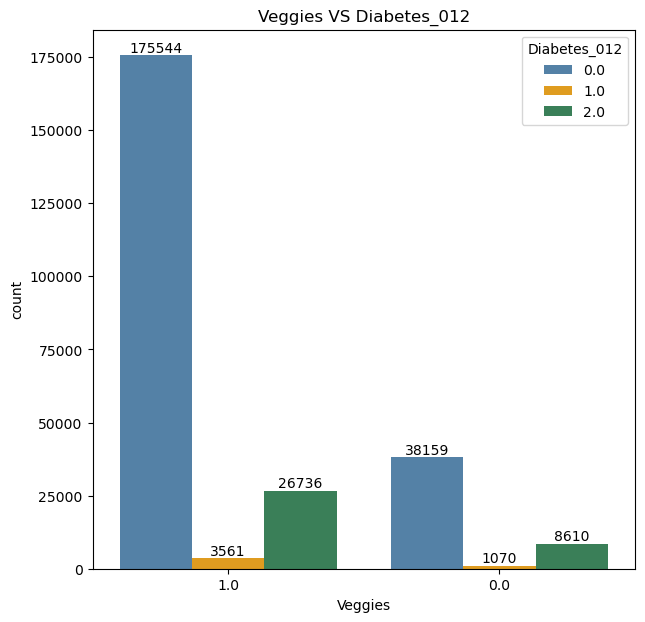

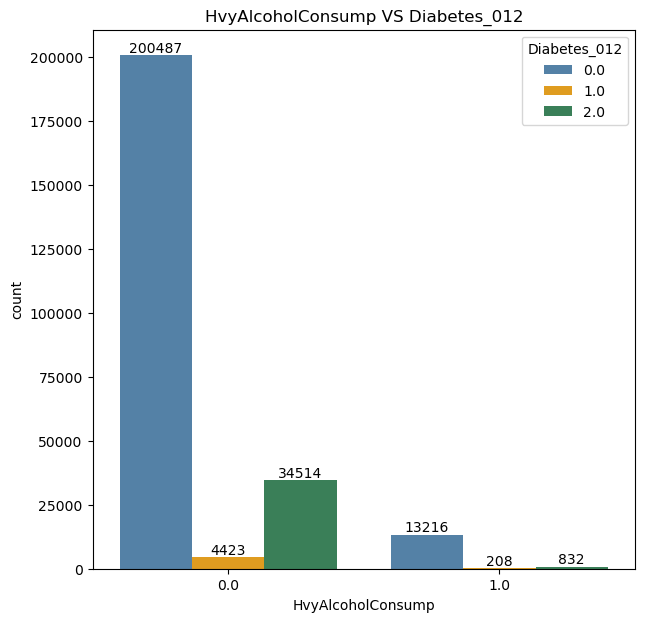

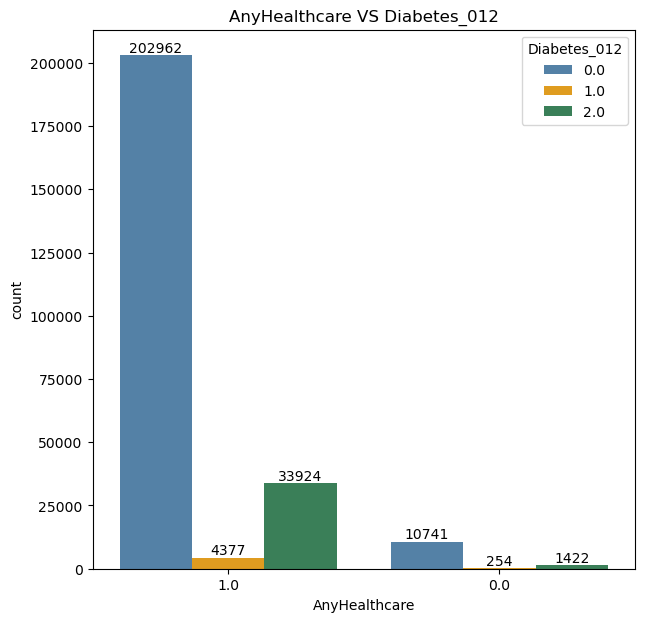

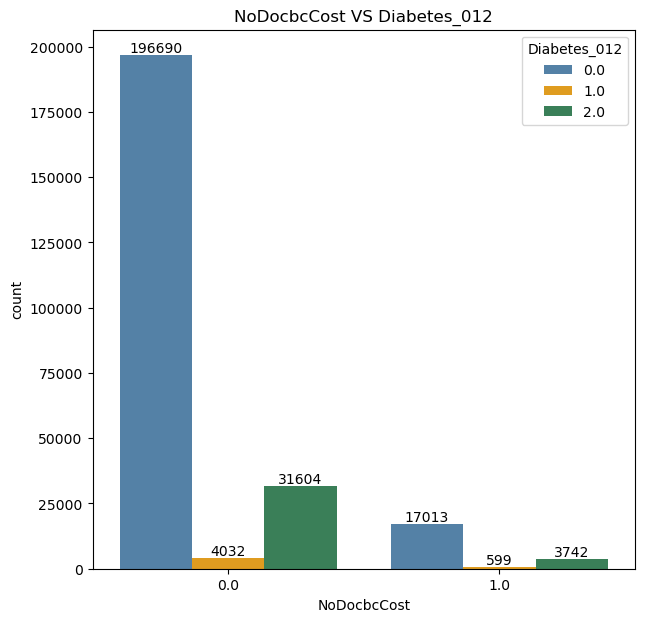

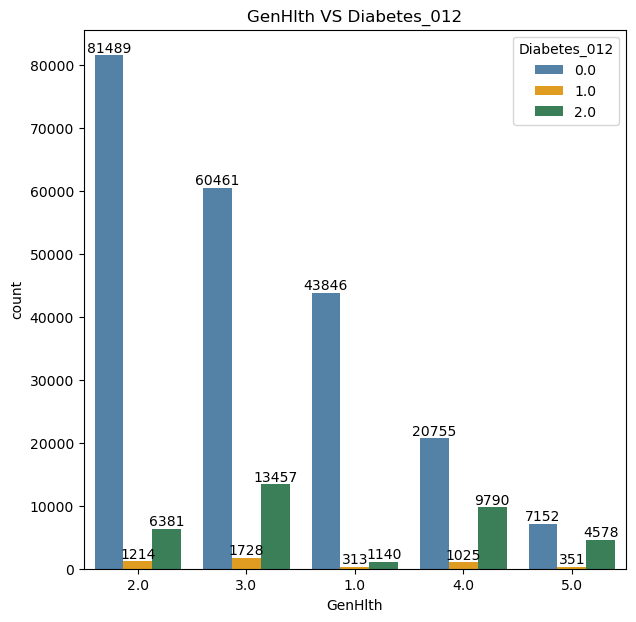

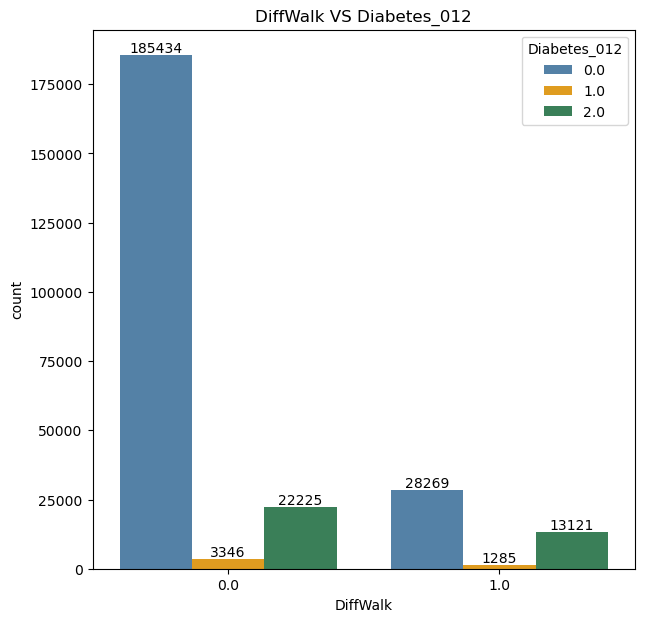

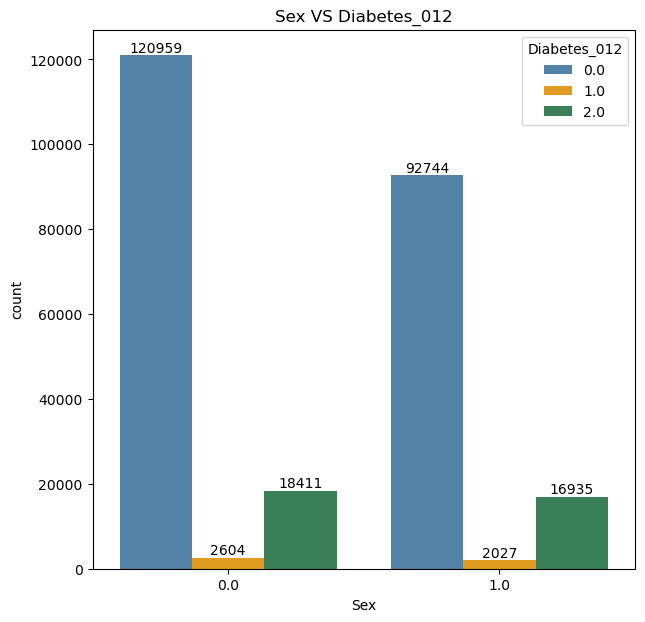

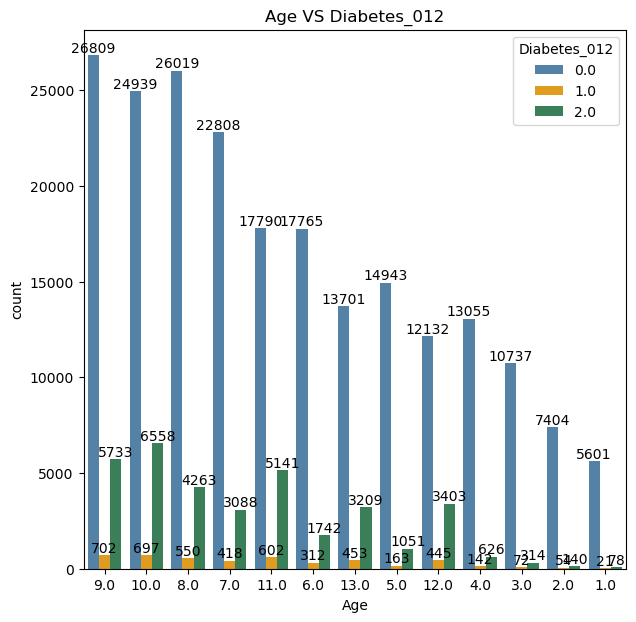

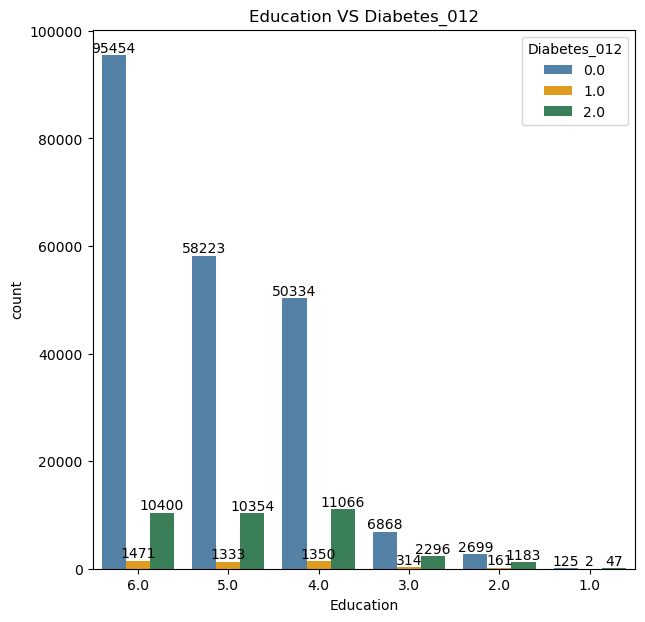

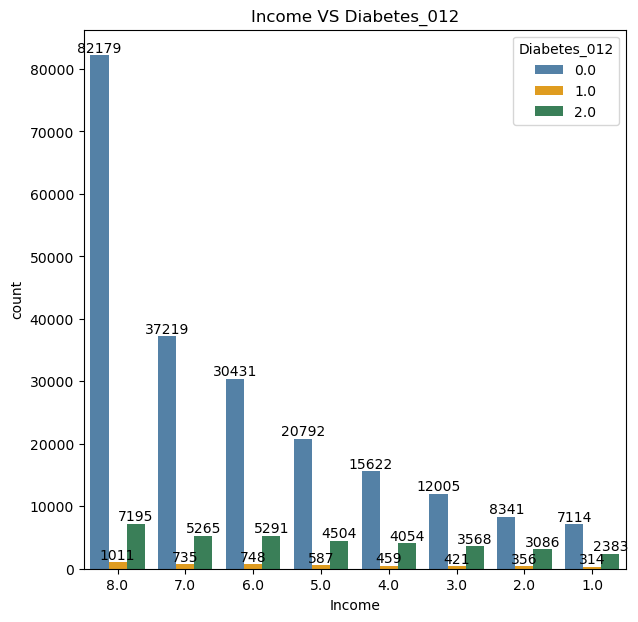

In [25]:
cat_vs_target(
    df,
    cat_features_dist,
    target
)

## Rate Categorical

In [26]:
def rate_categorical(df, feature, target) :
    for col in feature :
        rate = pd.crosstab(
            df[col],
            df[target],
            normalize='index',
        ) * 100

        print(f'{target} Default Rate Based on {col}')
        print(rate)
        ax = rate.plot(
            kind='bar',
            figsize=(7,7)
        )

        for container in ax.containers:
            ax.bar_label(
            container,
            fmt='%.1f%%',
            padding=2
        )
    
        plt.title(f'{target} Distribution Based on {col}')
        plt.xlabel(col)
        plt.ylabel('Percentage (%)')
        plt.legend(title=target)
        plt.tight_layout()
        plt.show()

Diabetes_012 Default Rate Based on HighBP
Diabetes_012        0.0       1.0        2.0
HighBP                                      
0.0           92.778786  1.186046   6.035167
1.0           72.877634  2.676676  24.445690


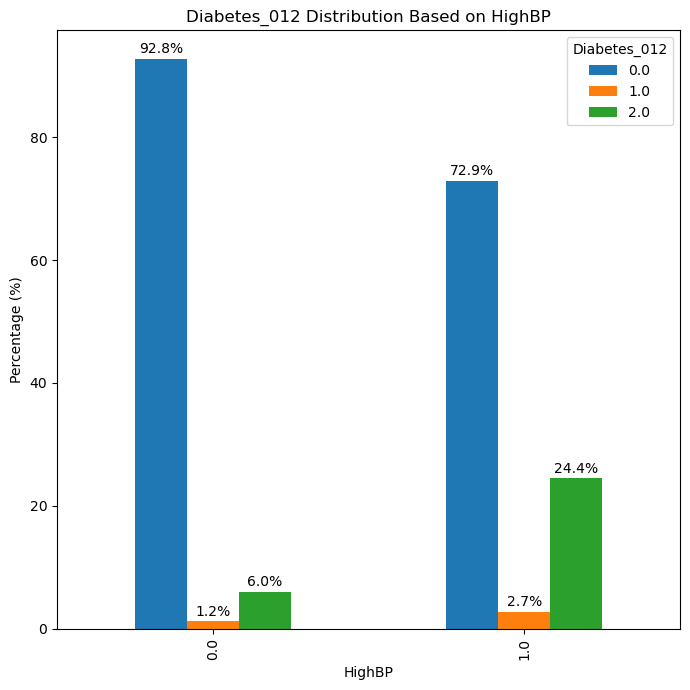

Diabetes_012 Default Rate Based on HighChol
Diabetes_012        0.0       1.0        2.0
HighChol                                    
0.0           90.816557  1.202007   7.981436
1.0           75.312991  2.672157  22.014853


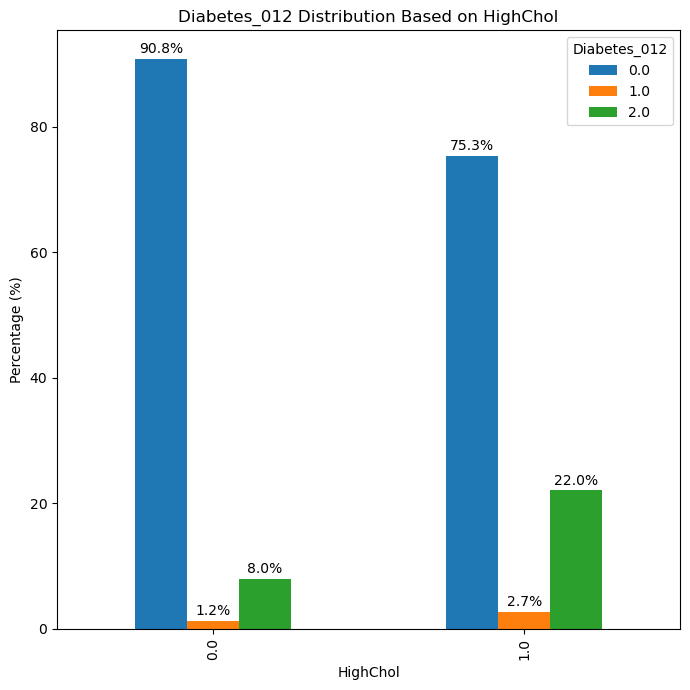

Diabetes_012 Default Rate Based on CholCheck
Diabetes_012        0.0       1.0        2.0
CholCheck                                   
0.0           96.800422  0.654699   2.544879
1.0           83.754146  1.870931  14.374923


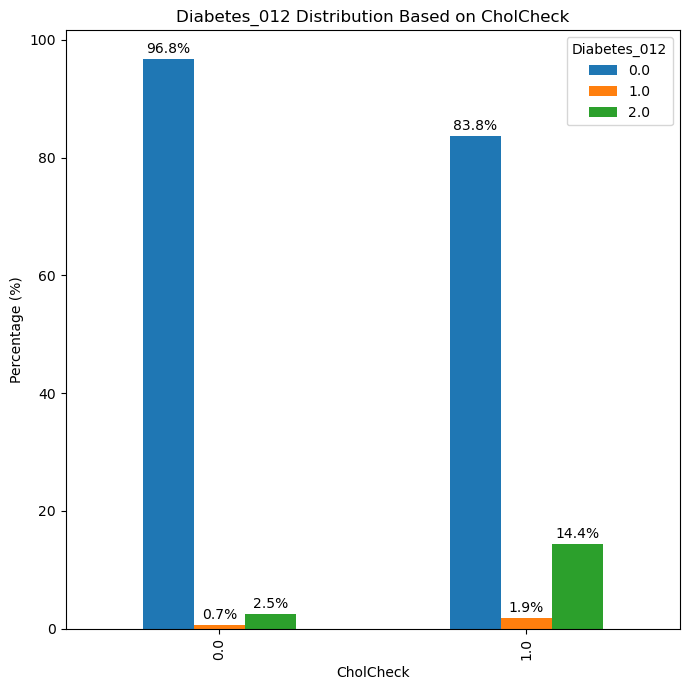

Diabetes_012 Default Rate Based on Smoker
Diabetes_012        0.0       1.0        2.0
Smoker                                      
0.0           86.281742  1.662926  12.055332
1.0           81.677237  2.029834  16.292929


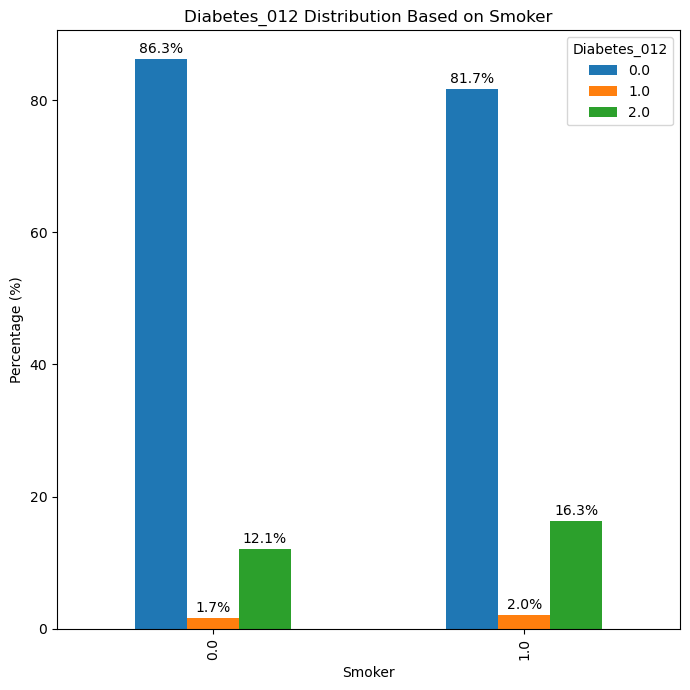

Diabetes_012 Default Rate Based on Stroke
Diabetes_012        0.0       1.0        2.0
Stroke                                      
0.0           85.026378  1.793844  13.179779
1.0           65.672367  2.574815  31.752818


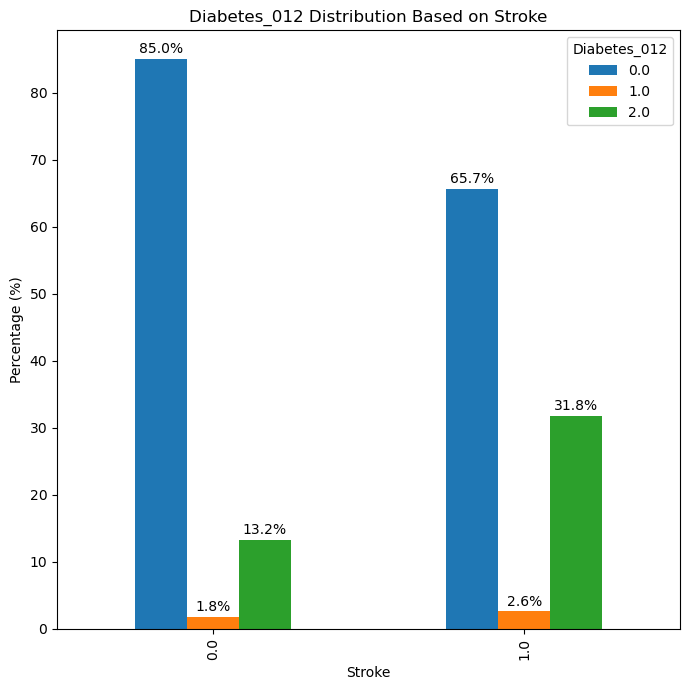

Diabetes_012 Default Rate Based on HeartDiseaseorAttack
Diabetes_012                0.0       1.0        2.0
HeartDiseaseorAttack                                
0.0                   86.319940  1.726381  11.953679
1.0                   64.248943  2.779057  32.972000


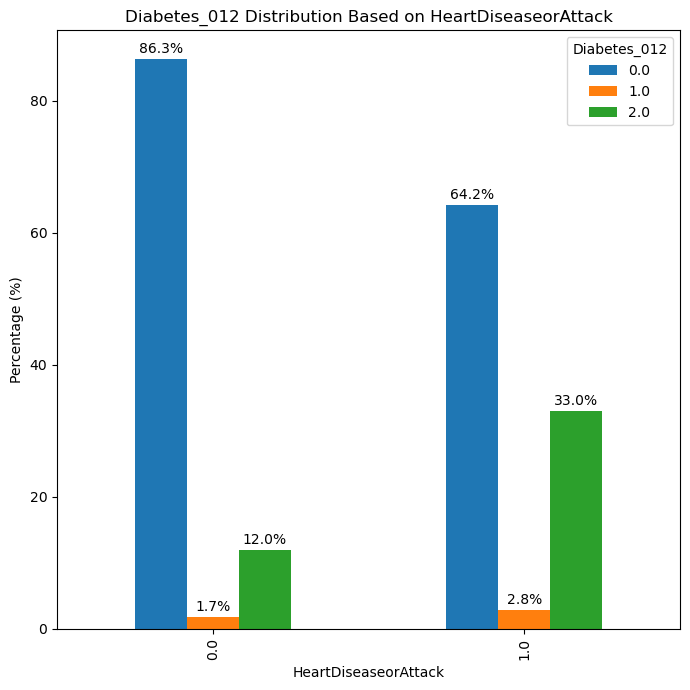

Diabetes_012 Default Rate Based on PhysActivity
Diabetes_012        0.0       1.0        2.0
PhysActivity                                
0.0           76.444301  2.410946  21.144754
1.0           86.750208  1.637140  11.612651


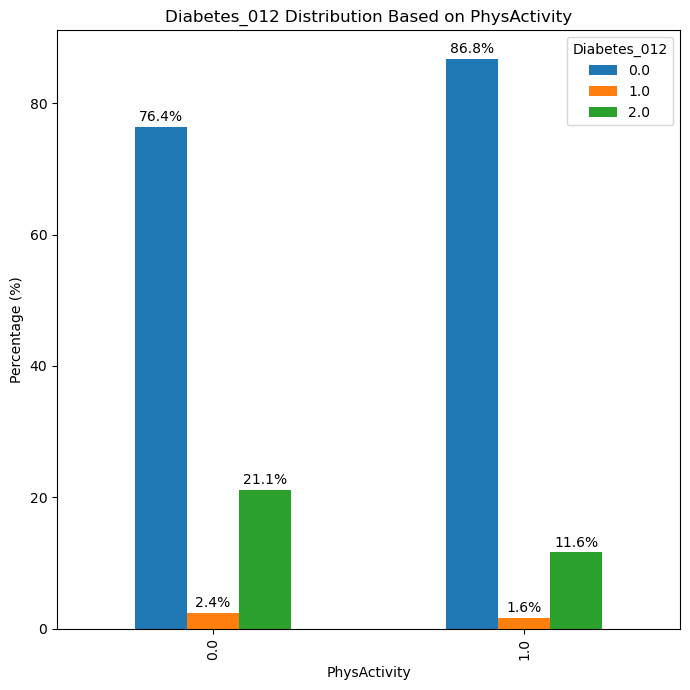

Diabetes_012 Default Rate Based on Fruits
Diabetes_012        0.0       1.0        2.0
Fruits                                      
0.0           82.221767  1.985299  15.792934
1.0           85.405661  1.733396  12.860943


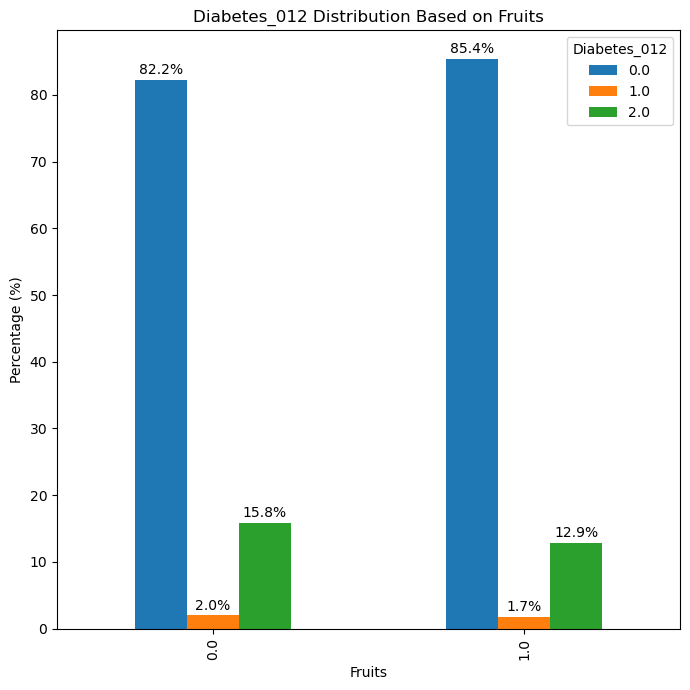

Diabetes_012 Default Rate Based on Veggies
Diabetes_012        0.0       1.0        2.0
Veggies                                     
0.0           79.765463  2.236669  17.997868
1.0           85.281358  1.729976  12.988666


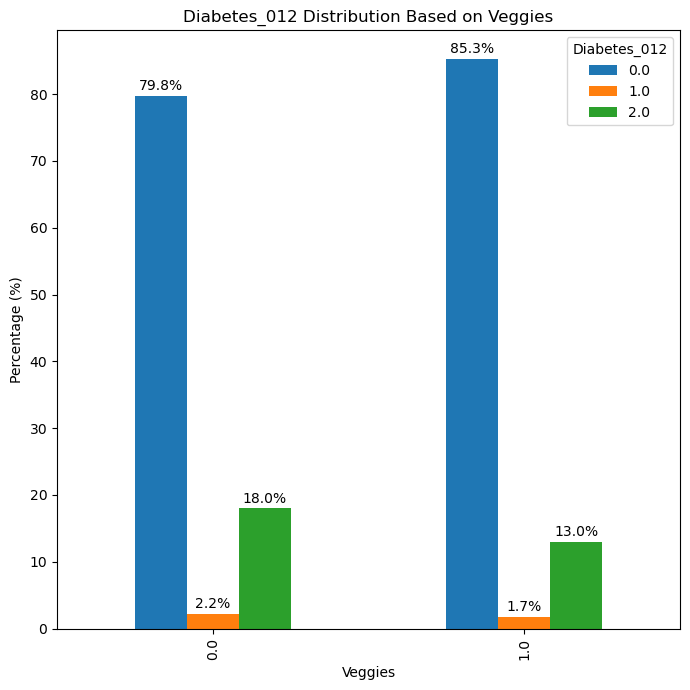

Diabetes_012 Default Rate Based on HvyAlcoholConsump
Diabetes_012             0.0       1.0        2.0
HvyAlcoholConsump                                
0.0                83.737219  1.847350  14.415430
1.0                92.704826  1.459035   5.836139


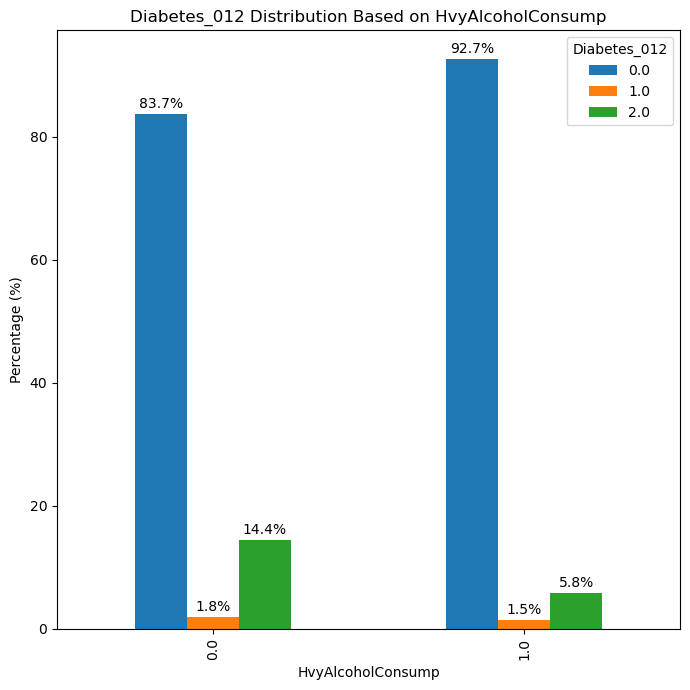

Diabetes_012 Default Rate Based on AnyHealthcare
Diabetes_012         0.0       1.0        2.0
AnyHealthcare                                
0.0            86.502376  2.045583  11.452042
1.0            84.124793  1.814203  14.061004


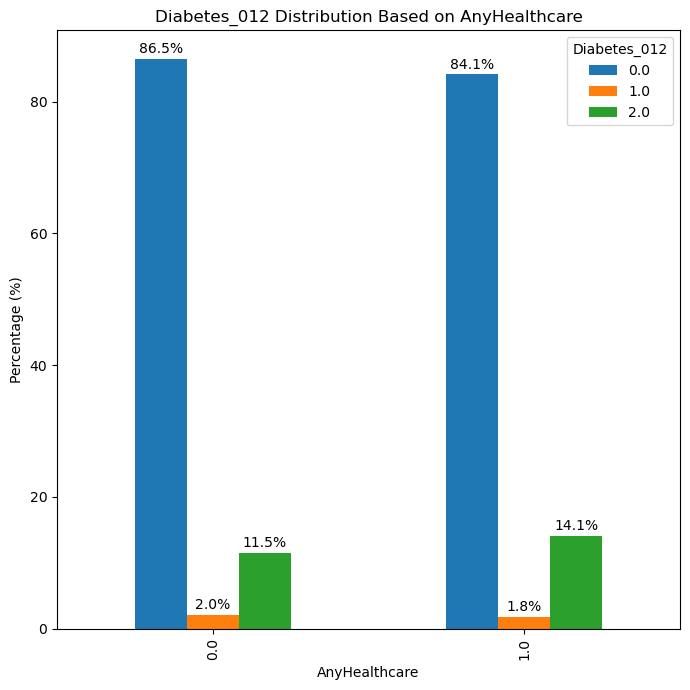

Diabetes_012 Default Rate Based on NoDocbcCost
Diabetes_012        0.0       1.0        2.0
NoDocbcCost                                 
0.0           84.661209  1.735492  13.603299
1.0           79.671256  2.805095  17.523649


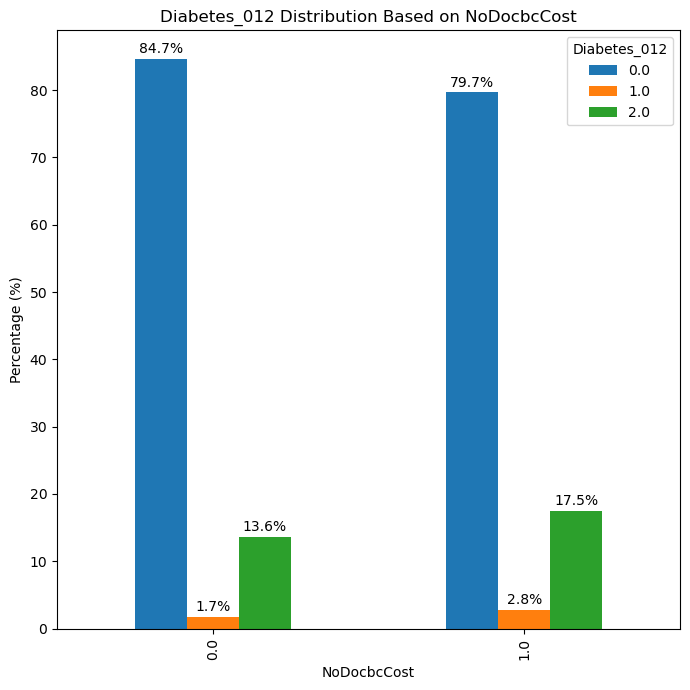

Diabetes_012 Default Rate Based on GenHlth
Diabetes_012        0.0       1.0        2.0
GenHlth                                     
1.0           96.792424  0.690964   2.516612
2.0           91.474339  1.362759   7.162902
3.0           79.926235  2.284324  17.789440
4.0           65.742794  3.246753  31.010453
5.0           59.200397  2.905389  37.894214


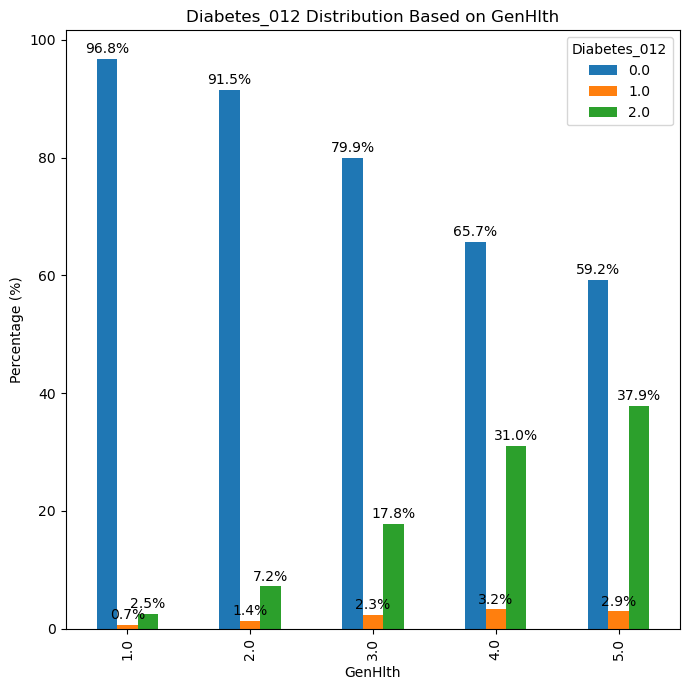

Diabetes_012 Default Rate Based on DiffWalk
Diabetes_012        0.0       1.0        2.0
DiffWalk                                    
0.0           87.881330  1.585744  10.532926
1.0           66.242531  3.011131  30.746339


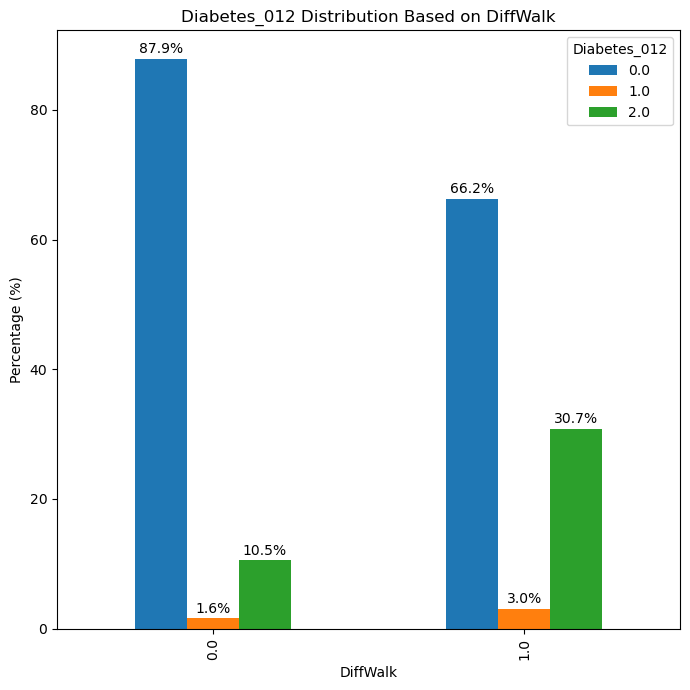

Diabetes_012 Default Rate Based on Sex
Diabetes_012        0.0       1.0        2.0
Sex                                         
0.0           85.197994  1.834139  12.967867
1.0           83.025084  1.814585  15.160332


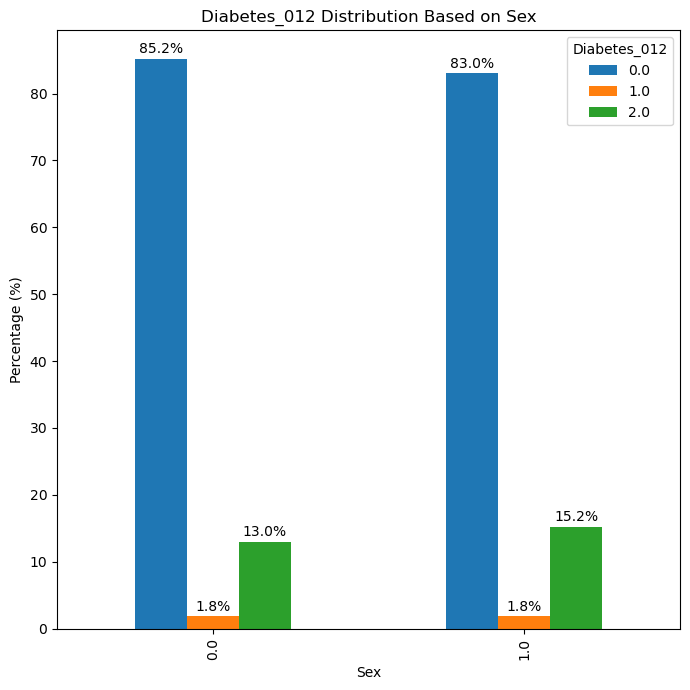

Diabetes_012 Default Rate Based on Age
Diabetes_012        0.0       1.0        2.0
Age                                         
1.0           98.263158  0.368421   1.368421
2.0           97.446696  0.710713   1.842590
3.0           96.529713  0.647307   2.822979
4.0           94.444043  1.027273   4.528684
5.0           92.486229  1.008851   6.504920
6.0           89.636208  1.574247   8.789545
7.0           86.676294  1.588508  11.735198
8.0           84.389595  1.783861  13.826544
9.0           80.643124  2.111659  17.245217
10.0          77.464745  2.165000  20.370255
11.0          75.595972  2.558110  21.845918
12.0          75.919900  2.784731  21.295369
13.0          78.909175  2.608996  18.481829


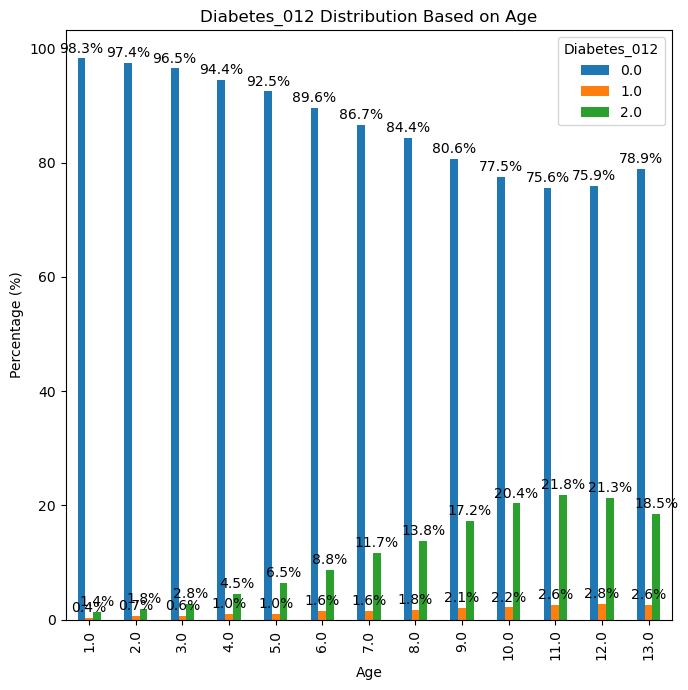

Diabetes_012 Default Rate Based on Education
Diabetes_012        0.0       1.0        2.0
Education                                   
1.0           71.839080  1.149425  27.011494
2.0           66.757358  3.982191  29.260450
3.0           72.462545  3.312935  24.224520
4.0           80.213546  2.151394  17.635060
5.0           83.282792  1.906737  14.810471
6.0           88.939203  1.370603   9.690193


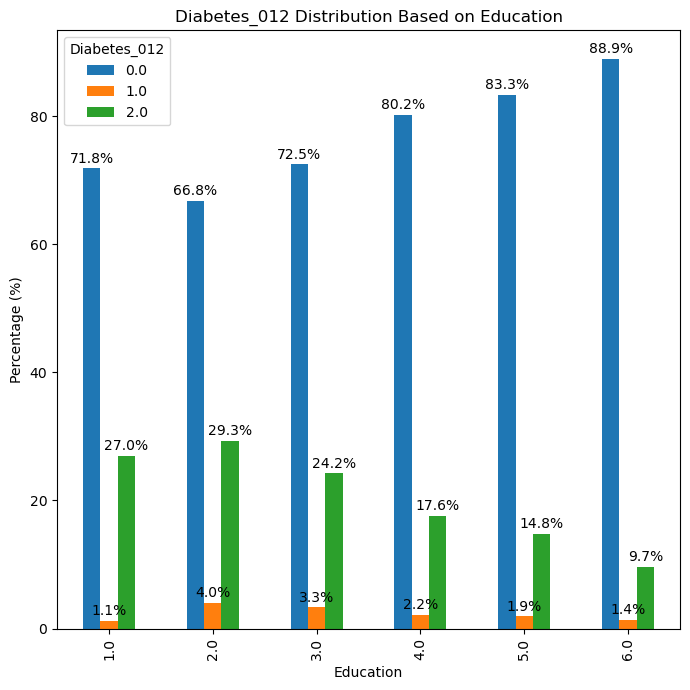

Diabetes_012 Default Rate Based on Income
Diabetes_012        0.0       1.0        2.0
Income                                      
1.0           72.510447  3.200489  24.289063
2.0           70.788424  3.021302  26.190274
3.0           75.059397  2.632237  22.308366
4.0           77.586293  2.279613  20.134095
5.0           80.330719  2.267898  17.401383
6.0           83.441185  2.051001  14.507815
7.0           86.117217  1.700641  12.182142
8.0           90.921060  1.118548   7.960392


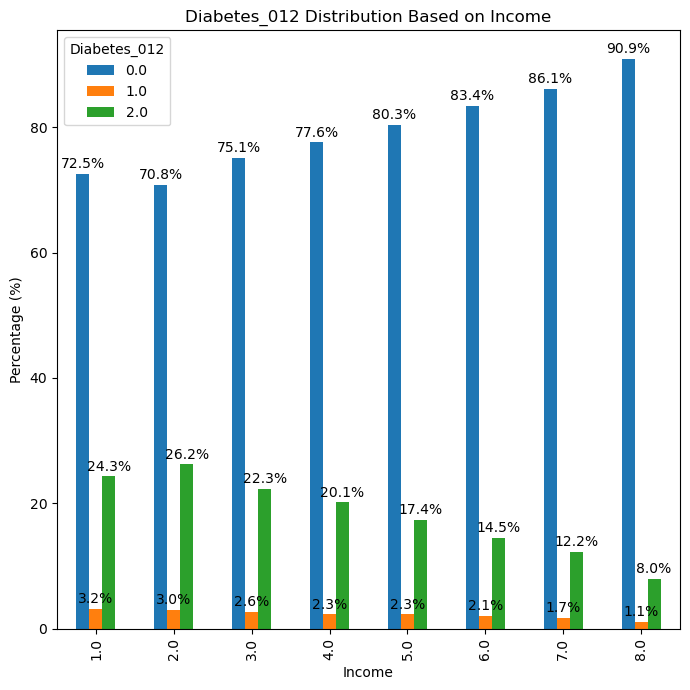

In [27]:
rate_categorical(
    df=df,
    feature = cat_features_dist,
    target=target
)

## Interpretation Rate Categorical
1. Very strong predictors (large differences in proportions, clear gradients):
- GenHlth: a near-perfect gradient — 2.5% (excellent) → 7.2% → 17.8% → 31.0% → 37.9% (poor). This is the strongest ordinal feature in the dataset.
- HeartDiseaseorAttack: 12.0% (no) → 33.0% (yes) — nearly a threefold increase.
- DiffWalk: 10.5% → 30.7% — difficulty walking is strongly associated with diabetes (logical, as diabetes complications often affect the nerves or blood vessels in the legs).
- HighBP: 6.0% → 24.4% — nearly a fourfold increase; one of the strongest predictors.
- Stroke: 13.2% → 31.8%.
- HighChol: 8.0% → 22.0%.

2. Socio-economic predictors (clear gradients, inverse relationship):
- Education: 27.0% (lowest level) decreasing gradually to 9.7% (highest level) — the higher the education, the lower the proportion of diabetes.
- Income: a similar pattern, from 24.3% (lowest income) to 8.0% (highest income).
- Age: rises sharply from 1.4% (youngest age group) to a peak of ~21–22% at codes 11–12 (around ages 70–79), then drops slightly at code 13 (age 80+) — likely due to survivor bias (diabetics with severe complications tend not to survive to very old age).

3. Predictors with counter-intuitive directions — require careful explanation in the report:
- CholCheck: those who routinely check their cholesterol actually have a higher proportion of diabetes (14.4%) compared to those who do not (2.5%). This does not mean checking cholesterol causes diabetes — it is more likely that people who already feel at risk or unwell visit the doctor more frequently (confounding by healthcare-seeking behavior). 
- HvyAlcoholConsump: heavy drinkers actually show a lower proportion of diabetes (5.8%) compared to non-heavy drinkers (14.4%)—this pattern is counter-intuitive, likely due to age confounding (heavy drinkers tend to be a younger population) or survivor bias.
- AnyHealthcare and NoDocbcCost: patterns similar to CholCheck—those with healthcare access or a history of doctor visits show a slightly higher proportion of diabetes; the causality is likely reversed (sick people visit the doctor more often, rather than doctor visits causing the illness).

4. Weak/moderate predictors:
- PhysActivity, Fruits, Veggies: mild protective effect (physically active: 11.6% vs. 21.1% inactive—this is actually quite strong), while the difference in fruit/vegetable consumption is narrower (~3 percentage points).
- Smoker, Sex: small differences (only a few percentage points); their contribution to the model is likely not as significant compared to the features mentioned above.

## Correlationmap for numerical features

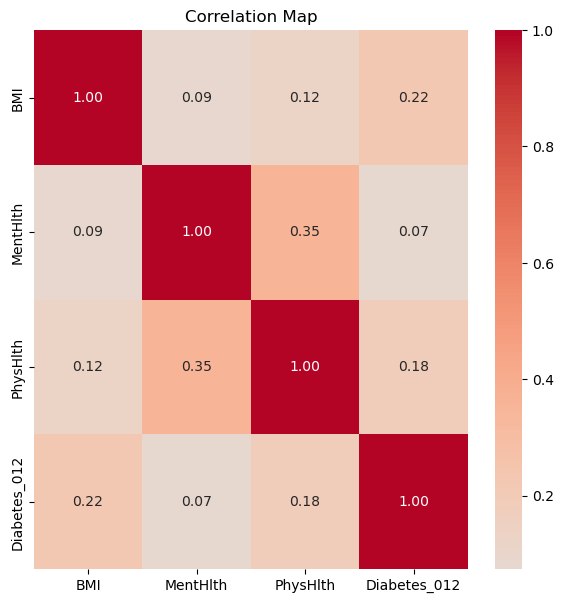

In [28]:
corr_features = num_features_dist + [target]

plt.figure(figsize=(7,7))

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Map")
plt.show()



## Chi Squared for Categorical Features

In [29]:
from scipy.stats import chi2_contingency

def cat_chi (df, features, target, alpha) :

    result_chi = []

    for feature in features :
        table = pd.crosstab(df[feature], df[target])

        chi_stats, p_value, dof, expected = chi2_contingency(table)
        result_chi.append({
            'feature' : feature,
            'chi2_squared' : chi_stats,
            'P Value' : p_value,
            'dof' : dof
        })

    df_result_chi = pd.DataFrame(result_chi)
    df_result_chi = df_result_chi.sort_values('P Value').reset_index(drop=True)
    df_result_chi['significant'] = df_result_chi['P Value'] < alpha

    return df_result_chi

In [30]:
chi_result = cat_chi(
    df=df,
    features=cat_features_dist,
    target=target,
    alpha=0.05
)

chi_result

,feature,chi2_squared,P Value,dof,significant
0,HighBP,18794.644052,0.000000e+00,2,True
1,HighChol,11258.920399,0.000000e+00,2,True
2,HeartDiseaseorAttack,8244.889107,0.000000e+00,2,True
3,Stroke,2916.751980,0.000000e+00,2,True
4,PhysActivity,3789.301463,0.000000e+00,2,True
5,GenHlth,24248.106147,0.000000e+00,8,True
6,Age,9641.376531,0.000000e+00,24,True
7,DiffWalk,12776.941889,0.000000e+00,2,True
8,Income,7816.462906,0.000000e+00,14,True
9,Education,4560.640279,0.000000e+00,10,True


## Interpretation Chi Squared
Every feature has Significante or P value < alpha but we but we should not immediately conclude if  `HighBP` has a stronger relationship than `HighChol` because its p-value is same

# Cramer's V 

In [31]:
def cramers_cat (df, features, target) :

    result_cramers = []

    for feature in features :
        table = pd.crosstab(df[feature], df[target])

        chi2, p_value, dof, expected = chi2_contingency(table)

        n = table.sum().sum()
        r, k = table.shape

        cramers_v = np.sqrt(
            chi2 / (n * min(r - 1, k - 1))
        )

        result_cramers.append({
            'feature' : feature,
            'chi2' : chi2,
            'P Value' : p_value,
            'cramers_v' : cramers_v
        })

    df_result_cramers = pd.DataFrame(result_cramers)
    df_result_cramers = df_result_cramers.sort_values(
        'cramers_v',
        ascending=False
    )

    return df_result_cramers

In [32]:
cramers_result = cramers_cat(
    df=df,
    features=cat_features_dist,
    target=target
)

cramers_result

,feature,chi2,P Value,cramers_v
0,HighBP,18794.644052,0.000000e+00,0.272191
13,DiffWalk,12776.941889,0.000000e+00,0.224425
12,GenHlth,24248.106147,0.000000e+00,0.218615
1,HighChol,11258.920399,0.000000e+00,0.210671
5,HeartDiseaseorAttack,8244.889107,0.000000e+00,0.180281
15,Age,9641.376531,0.000000e+00,0.137851
17,Income,7816.462906,0.000000e+00,0.124122
6,PhysActivity,3789.301463,0.000000e+00,0.122218
4,Stroke,2916.751980,0.000000e+00,0.107228
16,Education,4560.640279,0.000000e+00,0.094810


## Interpretation Cramers'V
It turns out to be true that `HighBP`(0.41) has the closest relationship with the target.

## Data Handling & Validation

In [33]:
df = df.drop_duplicates().reset_index(drop=True)

In [34]:
print(df.shape)
print(df.duplicated().sum())

(229781, 24)
0


# Splitting Data

In [35]:
from sklearn.model_selection import train_test_split

def splitting_data (
        df,
        target,
        test_size,
        random_state
) :
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = splitting_data(
    df=df,
    target=target,
    test_size=0.2,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape : {y_test.shape}')

print('\nTrain Target Distribution:')
print(y_train.value_counts(normalize=True).sort_index() * 100)

print('\nTest Target Distribution:')
print(y_test.value_counts(normalize=True).sort_index() * 100)

print(X_train.head())
print(y_train.value_counts())

X_train shape: (183824, 23)
X_test shape : (45957, 23)
y_train shape: (183824,)
y_test shape : (45957,)

Train Target Distribution:
Diabetes_012
0.0    82.711180
1.0     2.014427
2.0    15.274393
Name: proportion, dtype: float64

Test Target Distribution:
Diabetes_012
0.0    82.712100
1.0     2.014927
2.0    15.272973
Name: proportion, dtype: float64
        HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
12751      0.0       0.0        1.0  25.0     0.0     0.0   
191355     0.0       0.0        1.0  21.0     0.0     0.0   
102417     1.0       0.0        1.0  32.0     0.0     0.0   
58203      1.0       1.0        1.0  32.0     1.0     0.0   
47368      1.0       0.0        1.0  25.0     1.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  GenHlth  \
12751                    0.0           0.0     1.0      1.0  ...      2.0   
191355                   0.0           0.0     1.0      1.0  ...      2.0   
102417                   0.0           1.0     1.

# Train Basemodel

In [37]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline

def create_lgbm_model(
    random_state=42,
    class_weight=None
):
    model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        class_weight=class_weight,
        random_state=random_state
    )
    pipeline = Pipeline([
        ('model', model)
    ])

    return pipeline

In [38]:
def train_model(model, X_train, y_train):
    model.fit(
        X_train,
        y_train
    )
    return model

In [39]:
baseline_model = create_lgbm_model(
    class_weight=None
)

baseline_model = train_model(
    baseline_model,
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 183824, number of used features: 23
[LightGBM] [Info] Start training from score -0.189815
[LightGBM] [Info] Start training from score -3.904835
[LightGBM] [Info] Start training from score -1.878992


# Evaluate Model

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )
    print("Classification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [41]:
baseline_evaluate = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

for metric, value in baseline_evaluate.items() :
    print(f'{metric} : {value:.2f}')

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.59      0.19      0.28      7019

    accuracy                           0.84     45957
   macro avg       0.48      0.39      0.40     45957
weighted avg       0.79      0.84      0.80     45957

accuracy : 0.84
precision : 0.48
recall : 0.39
f1_score : 0.40


# Confuse Matrix

In [42]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

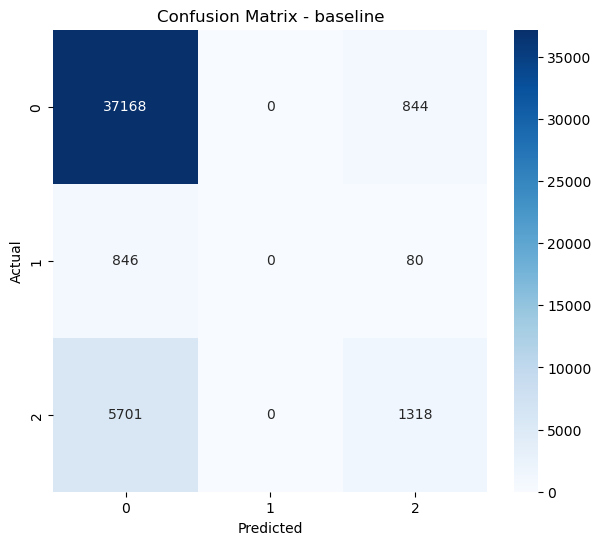

In [43]:
baseline_cm = plot_confusion_matrix(
    baseline_model,
    X_test,
    y_test,
    'baseline'
)

# Imbalanced Model

In [44]:
imbalanced_model = create_lgbm_model(
    class_weight='balanced'
)

imbalanced_model = train_model(
    baseline_model,
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 183824, number of used features: 23
[LightGBM] [Info] Start training from score -0.189815
[LightGBM] [Info] Start training from score -3.904835
[LightGBM] [Info] Start training from score -1.878992


In [47]:
imbalanced_evaluate = evaluate_model(
    baseline_model,
    X_test,
    y_test,
)

for metric, value in imbalanced_evaluate.items() :
    print(f'{metric} : {value:.2f}')

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.59      0.19      0.28      7019

    accuracy                           0.84     45957
   macro avg       0.48      0.39      0.40     45957
weighted avg       0.79      0.84      0.80     45957

accuracy : 0.84
precision : 0.48
recall : 0.39
f1_score : 0.40


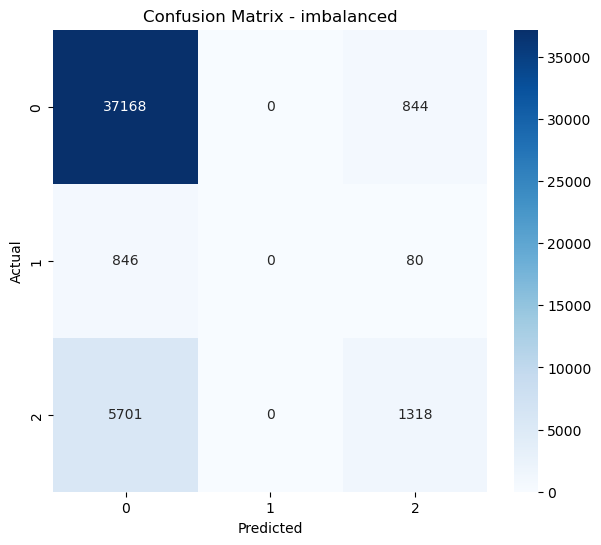

In [48]:
imbalanced_cm = plot_confusion_matrix(
    imbalanced_model,
    X_test,
    y_test,
    'imbalanced'
)

# Cross Validation

In [49]:
from sklearn.model_selection import StratifiedKFold


def create_cv(
    n_splits=5,
    random_state=42
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    return cv

In [50]:
cv = create_cv(
    n_splits=5,
    random_state=42
)

In [ ]:
from sklearn.model_selection import cross_validate

def run_cross_validation(
    model,
    X_train,
    y_train,
    cv
):
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro',
        'recall': 'recall_macro',
        'f1': 'f1_macro'
    }
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    return cv_results

# Functions Summarize CV

In [ ]:
import pandas as pd


def summarize_cv_results(
    cv_results,
    model_name
):
    result = {
        'model': model_name,
        'accuracy_mean': cv_results['test_accuracy'].mean(),
        'accuracy_std': cv_results['test_accuracy'].std(),
        'precision_mean': cv_results['test_precision'].mean(),
        'precision_std': cv_results['test_precision'].std(),
        'recall_mean': cv_results['test_recall'].mean(),
        'recall_std': cv_results['test_recall'].std(),
        'f1_mean':  cv_results['test_f1'].mean(),
        'f1_std': cv_results['test_f1'].std()
    }
    return pd.DataFrame([result])

# CV for Baseline

In [ ]:
cv = create_cv(
    n_splits=5,
    random_state=42
)
baseline_model = create_lgbm_model(
    class_weight=None
)
baseline_cv = run_cross_validation(
    baseline_model,
    X_train,
    y_train,
    cv
)
baseline_result = summarize_cv_results(
    baseline_cv,
    model_name='Baseline'
)
baseline_result

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -0.189817
[LightGBM] [Info] Start training from score -3.904632
[LightGBM] [Info] Start training from score -1.879009


c:\Users\ROG\anaconda3\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -0.189817
[LightGBM] [Info] Start training from score -3.904969
[LightGBM] [Info] Start training from score -1.878964


c:\Users\ROG\anaconda3\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -0.189817
[LightGBM] [Info] Start training from score -3.904969
[LightGBM] [Info] Start training from score -1.878964


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -0.189809
[LightGBM] [Info] Start training from score -3.904969
[LightGBM] [Info] Start training from score -1.879009


c:\Users\ROG\anaconda3\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147060, number of used features: 23
[LightGBM] [Info] Start training from score -0.189816
[LightGBM] [Info] Start training from score -3.904638
[LightGBM] [Info] Start training from score -1.879016


c:\Users\ROG\anaconda3\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Baseline,0.834837,0.00105,0.470014,0.004089,0.385298,0.002038,0.393426,0.002734


# CV for Imbalanced

In [ ]:
balanced_model = create_lgbm_model(
    class_weight='balanced'
)
balanced_cv = run_cross_validation(
    balanced_model,
    X_train,
    y_train,
    cv
)
balanced_result = summarize_cv_results(
    balanced_cv,
    model_name='Balanced'
)
balanced_result

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 23
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start 

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced,0.61653,0.004585,0.441548,0.00164,0.510002,0.004626,0.418434,0.002313


# CV Comparison

In [55]:
cv_comparison = pd.concat(
    [
        baseline_result,
        balanced_result
    ],
    ignore_index=True
)
cv_comparison

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Baseline,0.834837,0.001050,0.470014,0.004089,0.385298,0.002038,0.393426,0.002734
1,Balanced,0.616530,0.004585,0.441548,0.001640,0.510002,0.004626,0.418434,0.002313
